# NFL Contracts Predictions Capstone
## Research Question
  Can historical on-field performance data reliably predict the values for NFL Offensive position players' (QB, RB, WR, TE) next contract.

## Business Understanding
  The NFL salary cap is a year by year puzzle that can make or break the success of an NFL Franchise. Producing a model that is able to understand the fair market value for player contracts, given their recent and career production on the field will allow teams and players alike to better grasp and idea of a contract that makes sense and is actually possible.

## Data Sources
  The data obtained for this analysis come from the nflverse online Github Repository. This is a collection of curated NFL data scraped from the web to compile all significant data needed for analysis of the NFL. Some sources include OvertheCap, NFL API's and feeds from major sports reporting agencies.

## Data Structure
  I will be loading Data involving individual player statistics, overall team statistics, Contract data and schedule data. I will review all the data and engineer different features to include in my end model.

## Expected Results
  I anticipate being able to create a model that will take in key player production metrics and success that will predict appropriate contract values within an error of 2 million per year average.

# Data Understanding

In this section I will be loading in the NFL data from the 2000 to 2025 NFL seasons for understanding and selection. Given the broad range of data available, I will be looking to curate and engineer the features that will provide the most context for contract predictions.

In [193]:
# Installing nflreadypy library for NFL Verse Data import
!pip install nflreadpy

In [194]:
import pandas as pd
import numpy as np
import nflreadpy as nfl
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)

In [195]:
# Season range for last 25 years of NFL Data
START_SEASON = 2000
END_SEASON = 2025

seasons = list(range(START_SEASON, END_SEASON + 1))

print(f"Loading data for seasons: {START_SEASON}–{END_SEASON}")

Loading data for seasons: 2000–2025


In [196]:
# Loaded Data and Cast to Pandas Dataframe given original Data import as Polars DataFrames
raw_player_stats = (nfl.load_player_stats(seasons=seasons)).to_pandas()
raw_team_stats = (nfl.load_team_stats(seasons=seasons)).to_pandas()
raw_contracts = (nfl.load_contracts()).to_pandas()
raw_schedules = (nfl.load_schedules(seasons=seasons)).to_pandas()
print("Done!")

Done!


In [197]:
# Quick glance at the Player Stats Dataframes & Structure
display(raw_player_stats.head())
raw_player_stats.info()

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,fantasy_points,fantasy_points_ppr,game_id
0,0,None,None,None,None,None,2000,1,REG,SF,ATL,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,104,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.0,0.0,None
1,00-0000003,A.al-Jabbar,Abdul-Karim al-Jabbar,RB,RB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,IND,KC,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,1,-2,0,0,0,0,-0.549944,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,10,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,-0.2,-0.2,None
2,00-0000007,R.Abdullah,Rabih Abdullah,RB,RB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,TB,NE,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,1,1,3,0,0,0,0,0,0,-0.31212,0,0.0,0.041667,NaN,NaN,0,1,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.3,1.3,None
3,00-0000008,R.Abdullah,Rahim Abdullah,OLB,LB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,CLE,JAX,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,NaN,NaN,0,1,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.0,0.0,None
4,00-0000017,D.Abraham,Donnie Abraham,CB,DB,https://static.www.nfl.com/image/private/f_aut...,2000,1,REG,TB,NE,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,NaN,NaN,0,2,1,1,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.0,0.0,None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459317 entries, 0 to 459316
Columns: 115 entries, player_id to game_id
dtypes: float64(16), int32(86), object(13)
memory usage: 252.3+ MB


In [198]:
# Quick glance at the Contract Dataframes & Structure
display(raw_contracts.head())
raw_contracts.info()

,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,player_page,otc_id,gsis_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,cols
0,Joe Burrow,QB,Bengals,True,2023,5.0,275.000,55.000000,146.510,0.245,368.460854,73.692171,196.302544,https://overthecap.com/player/joe-burrow/8741/,8741,00-0036442,None,"6'4""",215,LSU,2020.0,1.0,1.0,Bengals,"[{'year': '2020', 'team': 'Bengals', 'base_sal..."
1,Aaron Rodgers,QB,GB/NYJ,False,2022,5.0,150.815,50.271667,101.415,0.241,218.181931,72.727311,146.715648,https://overthecap.com/player/aaron-rodgers/1085/,1085,00-0023459,None,"6'2""",225,California,2005.0,1.0,24.0,Packers,"[{'year': '2005', 'team': 'Packers', 'base_sal..."
2,Josh Allen,QB,Bills,False,2021,6.0,258.000,43.000000,100.000,0.236,425.806027,70.967671,165.041096,https://overthecap.com/player/josh-allen/6892/,6892,00-0034857,None,"6'5""",233,Wyoming,2018.0,1.0,7.0,Bills,"[{'year': '2018', 'team': 'Bills', 'base_salar..."
3,Russell Wilson,QB,Broncos,False,2022,5.0,245.000,49.000000,124.000,0.235,354.438040,70.887608,179.389049,https://overthecap.com/player/russell-wilson/1...,1569,00-0029263,"November 29, 1988","5'11""",206,Wisconsin,2012.0,3.0,75.0,Seahawks,"[{'year': '2012', 'team': 'Seahawks', 'base_sa..."
4,Dak Prescott,QB,Cowboys,True,2024,4.0,240.000,60.000000,129.000,0.235,283.038371,70.759593,152.133125,https://overthecap.com/player/dak-prescott/4848/,4848,00-0033077,None,"6'2""",226,Mississippi State,2016.0,4.0,135.0,Cowboys,"[{'year': '2016', 'team': 'Cowboys', 'base_sal..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51640 entries, 0 to 51639
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               51640 non-null  object 
 1   position             51640 non-null  object 
 2   team                 51640 non-null  object 
 3   is_active            51640 non-null  bool   
 4   year_signed          51640 non-null  int32  
 5   years                51615 non-null  float64
 6   value                51640 non-null  float64
 7   apy                  51640 non-null  float64
 8   guaranteed           51640 non-null  float64
 9   apy_cap_pct          51640 non-null  float64
 10  inflated_value       51640 non-null  float64
 11  inflated_apy         51640 non-null  float64
 12  inflated_guaranteed  51640 non-null  float64
 13  player_page          51640 non-null  object 
 14  otc_id               51640 non-null  int32  
 15  gsis_id              47456 non-null 

In [199]:
# Quick glance at the Team Stats Dataframes & Structure
display(raw_team_stats.head())
raw_team_stats.info()

,season,week,team,season_type,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,timeouts,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,game_id
0,2000,1,ARI,REG,NYG,28,49,318,2,3,1,-6,0,0,12,318,15,1.011349,NaN,0,20,43,0,1,1,4,-6.913380,0,28,47,318,2,0,0,12,0,15,2.382013,0,0,38,21,21,5,14,1,0.0,0.0,0,1,11,1,0,0,0,0,1,1,1,1,0,1,5,6,2,17,4,133,1,1,0,0,32.0,1.00,0,0,1,0,0,0,0,0,0,0,0,0,32,None,None,32,0,0,1,1,0,0,1.0,0,0,0,0,0,None
1,2000,1,ATL,REG,SF,16,31,264,2,0,0,0,0,0,0,264,13,10.218793,NaN,0,32,95,0,2,1,6,-11.639264,0,16,30,264,2,0,0,0,0,13,10.346253,0,0,41,10,10,1,6,3,1.0,6.0,1,1,36,4,1,0,0,0,0,0,0,0,0,4,51,3,2,21,5,145,5,5,0,0,48.0,1.00,0,1,0,4,0,0,0,0,0,0,0,0,43;44;24;44;48,None,None,203,0,0,3,3,0,0,1.0,0,0,0,0,0,None
2,2000,1,BAL,REG,PIT,18,32,199,1,0,1,-3,0,0,0,199,9,2.892977,NaN,0,36,140,0,0,0,9,-0.812932,0,18,30,199,1,0,0,0,0,9,5.271726,0,0,28,8,14,2,12,2,1.0,6.0,0,0,0,6,0,0,0,0,0,0,1,1,0,6,42,4,5,50,1,38,3,3,0,0,33.0,1.00,0,2,1,0,0,0,0,0,0,0,0,0,23;26;33,None,None,82,0,0,1,1,0,0,1.0,0,0,0,0,0,None
3,2000,1,BUF,REG,TEN,13,26,174,1,0,5,-37,0,0,0,174,9,-4.197206,NaN,0,35,129,0,0,0,6,-10.088240,0,13,24,174,1,0,0,0,0,9,2.890964,0,0,36,7,21,3,24,1,4.0,33.0,3,1,8,6,0,0,0,0,0,0,0,0,0,6,91,3,5,10,3,35,3,4,1,0,42.0,0.75,0,0,1,2,0,0,0,0,0,0,1,0,42;41;33,51,None,116,51,0,1,1,0,0,1.0,1,1,0,0,33,None
4,2000,1,CAR,REG,WAS,17,26,183,1,0,6,-59,1,1,0,183,6,-3.202182,NaN,0,20,112,0,0,0,4,-0.356698,0,17,25,183,1,0,0,0,0,6,6.882382,0,1,49,7,7,3,3,0,0.0,0.0,0,0,0,4,0,0,0,0,0,0,0,0,0,9,65,2,0,0,5,189,1,2,1,0,29.0,0.50,0,1,0,0,0,0,0,1,0,0,0,0,29,27,None,29,27,0,2,2,0,0,1.0,0,0,0,0,0,None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14014 entries, 0 to 14013
Columns: 103 entries, season to game_id
dtypes: float64(9), int32(87), object(7)
memory usage: 6.4+ MB


In [200]:
# Quick glance at the Schedules Dataframes & Structure
display(raw_schedules.head())
raw_schedules.info()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,2000_01_SF_ATL,2000,REG,1,2000-09-03,Sunday,13:00,SF,28,ATL,36,Home,8,64,0,2000090310,998,None,200009030atl,NaN,200903001,NaN,7,7,NaN,NaN,6.5,NaN,NaN,46.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005755,00-0002876,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,ATL00,Georgia Dome
1,2000_01_JAX_CLE,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27,CLE,7,Home,-20,34,0,2000090306,994,None,200009030cle,NaN,200903005,NaN,7,7,NaN,NaN,-10.5,NaN,NaN,38.5,NaN,NaN,1,outdoors,grass,78.0,6.0,00-0002110,00-0003535,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,CLE00,Cleveland Browns Stadium
2,2000_01_IND_KC,2000,REG,1,2000-09-03,Sunday,13:00,IND,27,KC,14,Home,-13,41,0,2000090305,993,None,200009030kan,NaN,200903012,NaN,7,7,NaN,NaN,-3.5,NaN,NaN,44.0,NaN,NaN,0,outdoors,grass,90.0,5.0,00-0010346,00-0006300,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,KAN00,Arrowhead Stadium
3,2000_01_CHI_MIN,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27,MIN,30,Home,3,57,0,2000090303,991,None,200009030min,NaN,200903016,NaN,7,7,NaN,NaN,4.5,NaN,NaN,46.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0011044,00-0003739,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,MIN00,Hubert H. Humphrey Metrodome
4,2000_01_TB_NE,2000,REG,1,2000-09-03,Sunday,13:00,TB,21,NE,16,Home,-5,37,0,2000090312,1000,None,200009030nwe,NaN,200903017,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,36.0,NaN,NaN,0,outdoors,grass,71.0,5.0,00-0009266,00-0001361,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,BOS99,Foxboro Stadium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           7017 non-null   object 
 1   season            7017 non-null   int32  
 2   game_type         7017 non-null   object 
 3   week              7017 non-null   int32  
 4   gameday           7017 non-null   object 
 5   weekday           7017 non-null   object 
 6   gametime          7017 non-null   object 
 7   away_team         7017 non-null   object 
 8   away_score        7017 non-null   int32  
 9   home_team         7017 non-null   object 
 10  home_score        7017 non-null   int32  
 11  location          7017 non-null   object 
 12  result            7017 non-null   int32  
 13  total             7017 non-null   int32  
 14  overtime          7017 non-null   int32  
 15  old_game_id       7017 non-null   object 
 16  gsis              7017 non-null   int32  


### Data Descriptions

Findings from initial glances at the raw data:


*   raw_player_stats - The player stats is currently formated on a week by week stats basis, including the post season. This format will need to be addressed and curated for our use case.  

*   raw_contracts - Contract data provides us an abundance of information, some of which that could potentially be disregarded. We will look to utilize a subset of the data available.  

*   raw_team_stats - Much like the player stats data, it is currently provided to us on a week by week basis, including opponent. We will need to address this and format it to better utilize for our model.  

*   raw_schedules - this data provides us with all the information possibly needed for each game, from start time to location. We will use this to extrapolate team wins as well as QB specific wins since that is a strong factor in contract valuations, or so it seems.

For our use case, we want to focus on the QB, RB, WR & TE position so we will filter out all data specific to those positions.

In [201]:
# Want to filter player specific dataframes to only positions of interest.
OFF_POSITIONS = ["QB", "RB", "WR", "TE"]

# Filter out player stats and contracts for those specific positions.
filt_player_stats = raw_player_stats[raw_player_stats['position'].isin(OFF_POSITIONS)].copy()
filt_contracts = raw_contracts[raw_contracts['position'].isin(OFF_POSITIONS)].copy()

# Initial Raw Data Exploration

In [202]:
#===============================
# Player Stats Data - Weekly
#===============================
# Look through all the columns in the data
# long list broken down into more visible area.
print(f'Player stats columns are as follows :')
quart = len(filt_player_stats.columns) // 10
for i , col in enumerate(filt_player_stats.columns):
  if i % quart == 0:
    print()
  print(col, end = ' / ')

Player stats columns are as follows :

player_id / player_name / player_display_name / position / position_group / headshot_url / season / week / season_type / team / opponent_team / 
completions / attempts / passing_yards / passing_tds / passing_interceptions / sacks_suffered / sack_yards_lost / sack_fumbles / sack_fumbles_lost / passing_air_yards / passing_yards_after_catch / 
passing_first_downs / passing_epa / passing_cpoe / passing_2pt_conversions / pacr / carries / rushing_yards / rushing_tds / rushing_fumbles / rushing_fumbles_lost / rushing_first_downs / 
rushing_epa / rushing_2pt_conversions / receptions / targets / receiving_yards / receiving_tds / receiving_fumbles / receiving_fumbles_lost / receiving_air_yards / receiving_yards_after_catch / receiving_first_downs / 
receiving_epa / receiving_2pt_conversions / racr / target_share / air_yards_share / wopr / special_teams_tds / def_tackles_solo / def_tackles_with_assist / def_tackle_assists / def_tackles_for_loss / 
def_tackle

In [203]:
# Understanding Missing if any
print(f'Column missing data is as follows :\n')
for col in filt_player_stats.columns:
  if filt_player_stats[col].isna().sum() > 0:
    print(f'{col.title()} has {filt_player_stats[col].isna().sum()} missing values')

Column missing data is as follows :

Headshot_Url has 5 missing values
Passing_Epa has 127742 missing values
Passing_Cpoe has 131871 missing values
Pacr has 128115 missing values
Rushing_Epa has 91580 missing values
Receiving_Epa has 41815 missing values
Racr has 43730 missing values
Target_Share has 30737 missing values
Air_Yards_Share has 21306 missing values
Wopr has 36532 missing values
Fg_Long has 144700 missing values
Fg_Pct has 144700 missing values
Fg_Made_List has 144700 missing values
Fg_Missed_List has 144702 missing values
Fg_Blocked_List has 144702 missing values
Pat_Pct has 144699 missing values
Game_Id has 126203 missing values


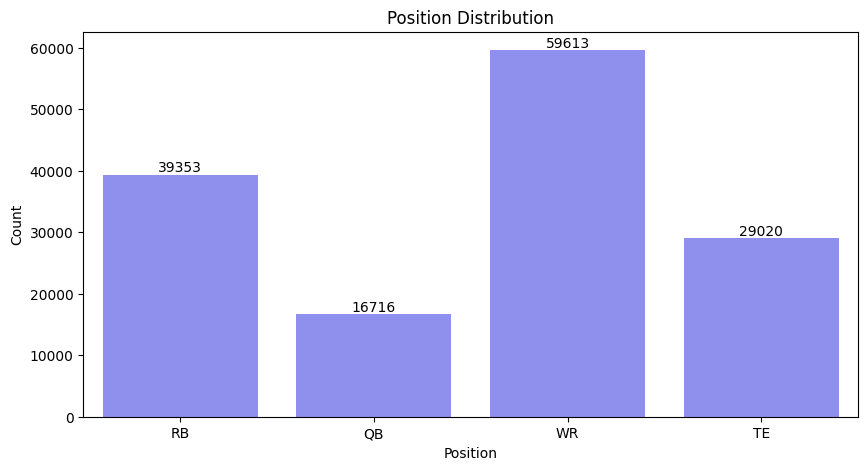

In [204]:
# Counts for positions in the dataframe.
plt.figure(figsize=(10, 5))
ax = sns.countplot(data = filt_player_stats, x = 'position' , alpha= 0.5, color = 'blue')
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Position Distribution')
ax.set_xlabel('Position')
ax.set_ylabel('Count')
plt.show()

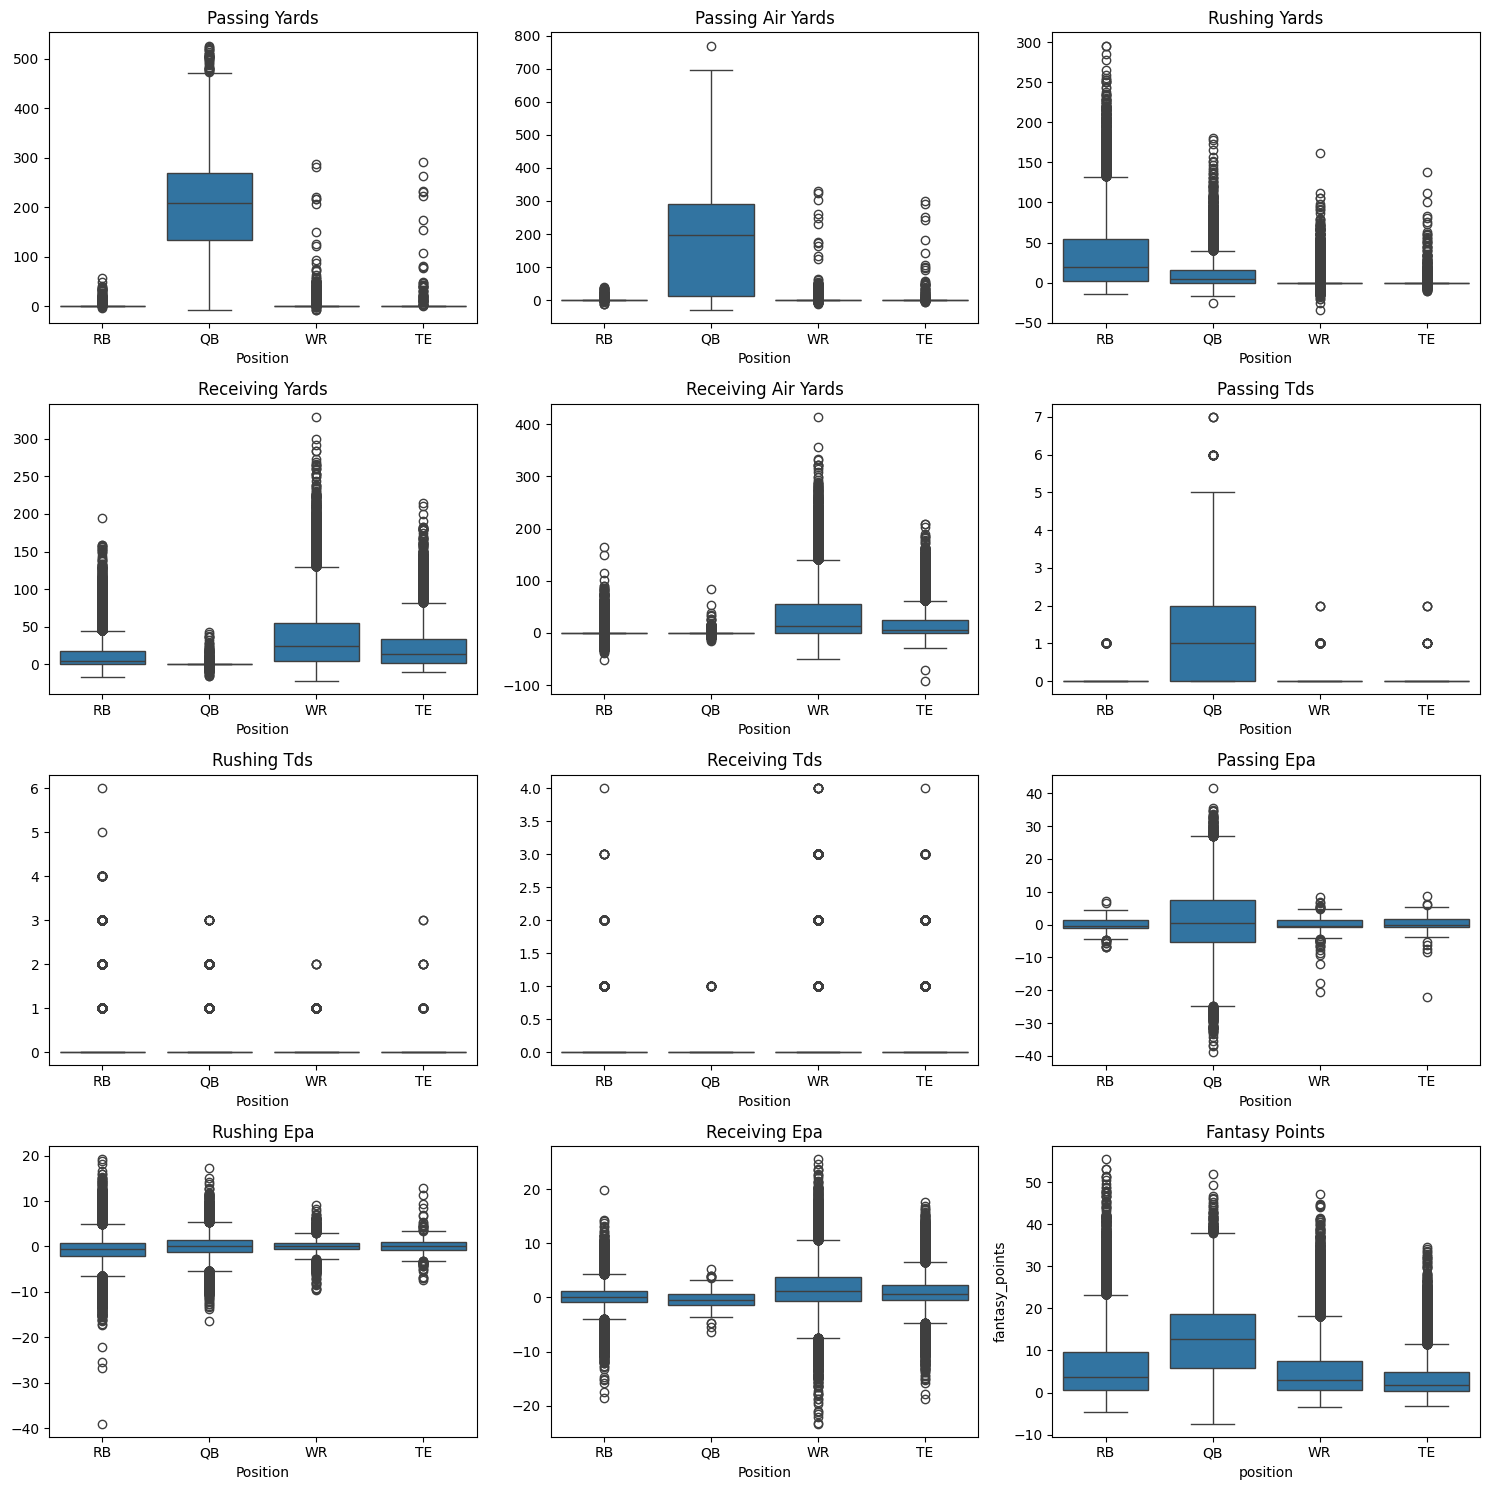

In [205]:
# Stats Box plots for positions
# All stats are weekly per player.

# Isolate the views of all yardage, tds and epa (Expected Points Added)
stats = ('_yards','_tds','_epa')
# Look at all 3 stat types
s_type = ('passing','rushing','receiving')
ovr_stats = []
# Estblish a list of Stats in columns
for stat in stats:
  matched = [col for col in filt_player_stats.columns
             if col.endswith(stat)
             and col.startswith(s_type)
             ]
  ovr_stats.extend(matched)
# Plot Box Plots of each Stat Category by Position
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
ax = ax.flatten()
for i, col in enumerate(ovr_stats):
    sns.boxplot(x='position', y=col, data=filt_player_stats, ax=ax[i])
    ax[i].set_title(col.replace("_", " ").title())
    ax[i].set_xlabel('Position')
    ax[i].set_ylabel('')
# Additional Fantasy Points column plotted, which has a correlation with player performance.
sns.boxplot(x='position', y='fantasy_points', data=filt_player_stats, ax=ax[11])
ax[11].set_title('Fantasy Points')
plt.tight_layout()
plt.show()

In [206]:
#====================================
# Contract Data Exploration
#====================================
print(f'Contract columns are as follows :\n')
mid = len(filt_contracts.columns) // 2
for i, col in enumerate(filt_contracts.columns):
  if i == mid:
    print()
  print(col, end = ' / ')


Contract columns are as follows :

player / position / team / is_active / year_signed / years / value / apy / guaranteed / apy_cap_pct / inflated_value / inflated_apy / 
inflated_guaranteed / player_page / otc_id / gsis_id / date_of_birth / height / weight / college / draft_year / draft_round / draft_overall / draft_team / cols / 

In [207]:
# Understanding Missing Entries if any
print(f'Column missing data is as follows :\n')
for col in filt_contracts.columns:
  if filt_contracts[col].isna().sum() > 0:
    print(f'{col.title()} has {filt_contracts[col].isna().sum()} missing values')

Column missing data is as follows :

Years has 6 missing values
Gsis_Id has 1595 missing values
Date_Of_Birth has 4476 missing values
Height has 600 missing values
Weight has 617 missing values
College has 374 missing values
Draft_Year has 282 missing values
Draft_Round has 9830 missing values
Draft_Overall has 9852 missing values
Draft_Team has 490 missing values
Cols has 1982 missing values


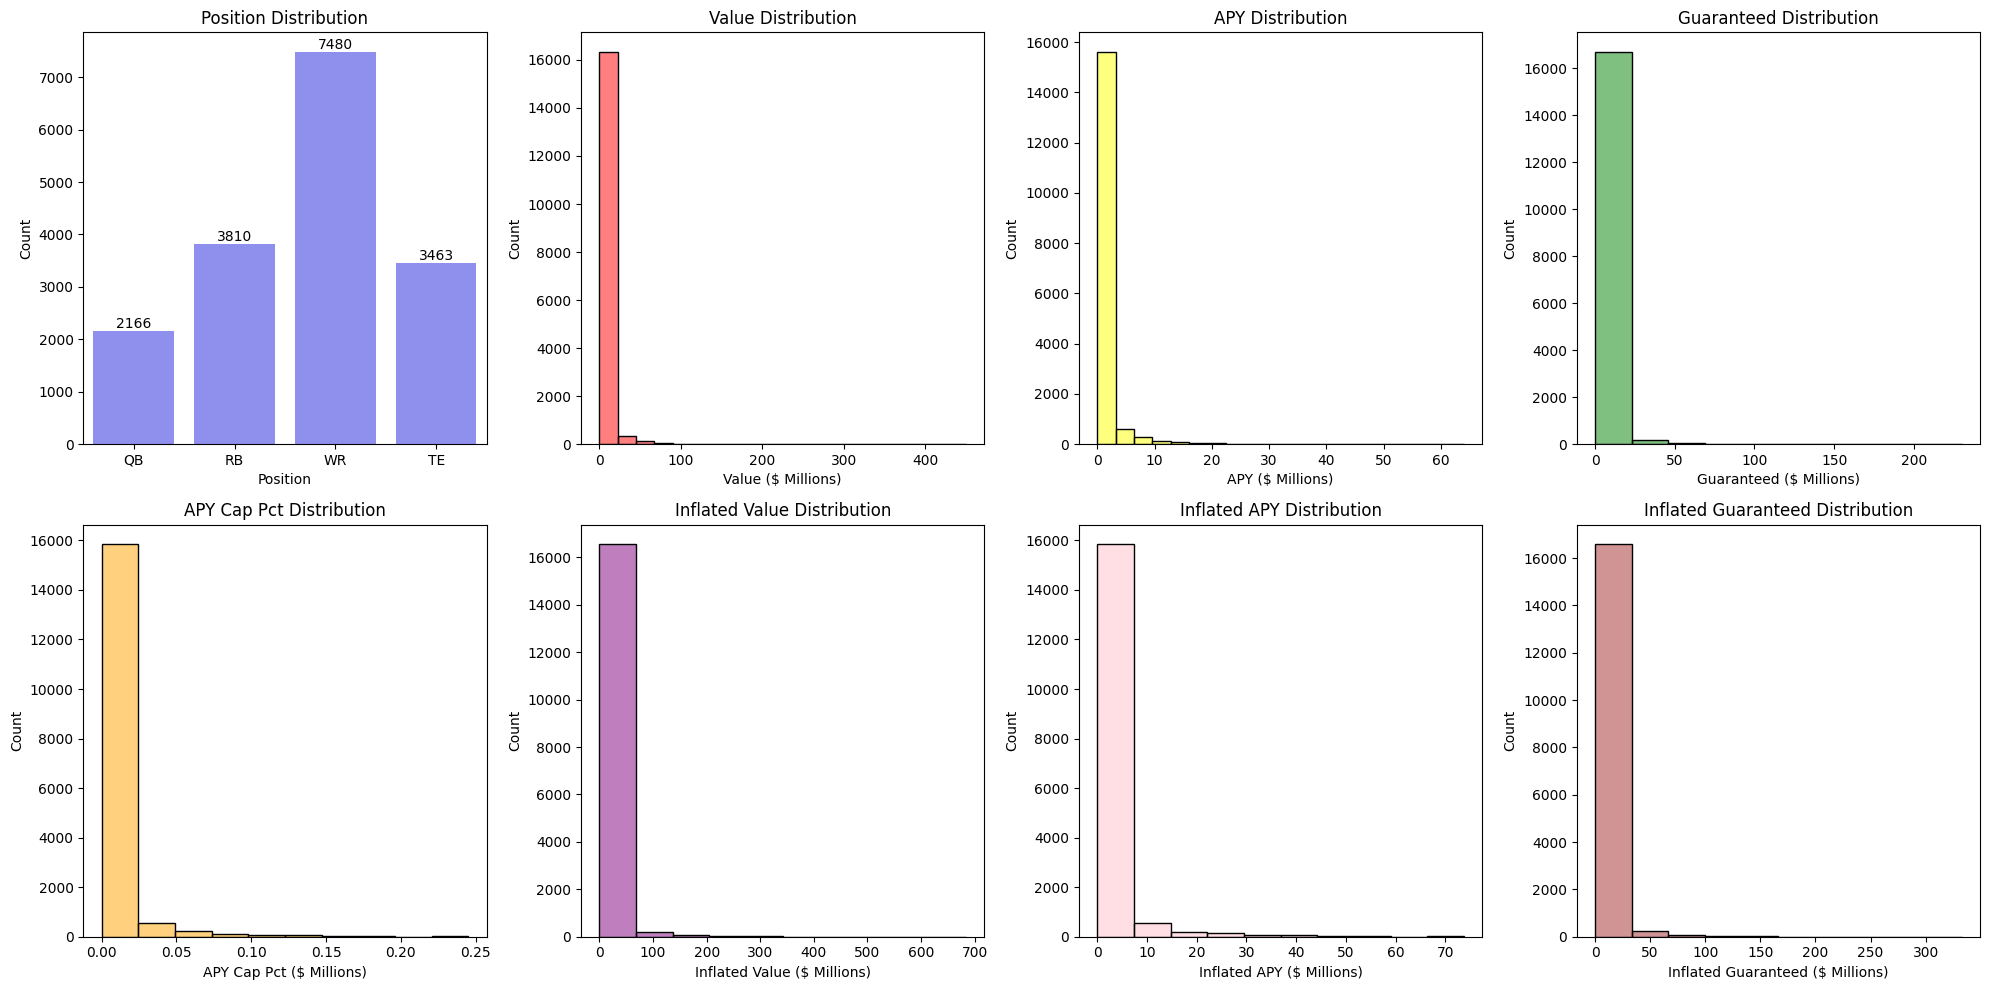

In [208]:
# Visualization of Data from Contracts Dataframe.
fig, ax = plt.subplots(ncols=4 , nrows=2, figsize=(20,10))
# Counts of position in dataframe
sns.countplot(data = filt_contracts, x = 'position', alpha= 0.5, color = 'blue', ax = ax[0,0])
for container in ax[0,0].containers:
    ax[0,0].bar_label(container)
ax[0,0].set_title('Position Distribution')
ax[0,0].set_xlabel('Position')
ax[0,0].set_ylabel('Count')
# Distribution of Value of Contracts
sns.histplot(data = filt_contracts, x = 'value', bins = 20,  alpha= 0.5, color = 'red', ax=ax[0,1])
ax[0,1].set_title('Value Distribution')
ax[0,1].set_xlabel('Value ($ Millions)')
ax[0,1].set_ylabel('Count')
# Distribution of APY of Contracts
sns.histplot(data = filt_contracts, x = 'apy', bins = 20, alpha= 0.5, color = 'yellow', ax=ax[0,2])
ax[0,2].set_title('APY Distribution')
ax[0,2].set_xlabel('APY ($ Millions)')
ax[0,2].set_ylabel('Count')
# Distribution of Guaranteed $ of Contracts
sns.histplot(data = filt_contracts, x = 'guaranteed', bins = 10,  alpha= 0.5, color = 'green', ax=ax[0,3])
ax[0,3].set_title('Guaranteed Distribution')
ax[0,3].set_xlabel('Guaranteed ($ Millions)')
ax[0,3].set_ylabel('Count')
# Distribution of APY Cap Percentages of Contracts
sns.histplot(data = filt_contracts, x = 'apy_cap_pct', bins = 10,  alpha= 0.5, color = 'orange', ax=ax[1,0])
ax[1,0].set_title('APY Cap Pct Distribution')
ax[1,0].set_xlabel('APY Cap Pct ($ Millions)')
ax[1,0].set_ylabel('Count')
# Distribution of Inflated Values of Contracts
sns.histplot(data = filt_contracts, x = 'inflated_value', bins = 10,  alpha= 0.5, color = 'purple', ax=ax[1,1])
ax[1,1].set_title('Inflated Value Distribution')
ax[1,1].set_xlabel('Inflated Value ($ Millions)')
ax[1,1].set_ylabel('Count')
# Distribution of Inflated APY of Contracts
sns.histplot(data = filt_contracts, x = 'inflated_apy', bins = 10,  alpha= 0.5, color = 'pink', ax=ax[1,2])
ax[1,2].set_title('Inflated APY Distribution')
ax[1,2].set_xlabel('Inflated APY ($ Millions)')
ax[1,2].set_ylabel('Count')
# Distribution of Inflated Guearanteed $ of Contracts
sns.histplot(data = filt_contracts, x = 'inflated_guaranteed', bins = 10,  alpha= 0.5, color = 'brown', ax=ax[1,3])
ax[1,3].set_title('Inflated Guaranteed Distribution')
ax[1,3].set_xlabel('Inflated Guaranteed ($ Millions)')
ax[1,3].set_ylabel('Count')
plt.tight_layout()
plt.show()

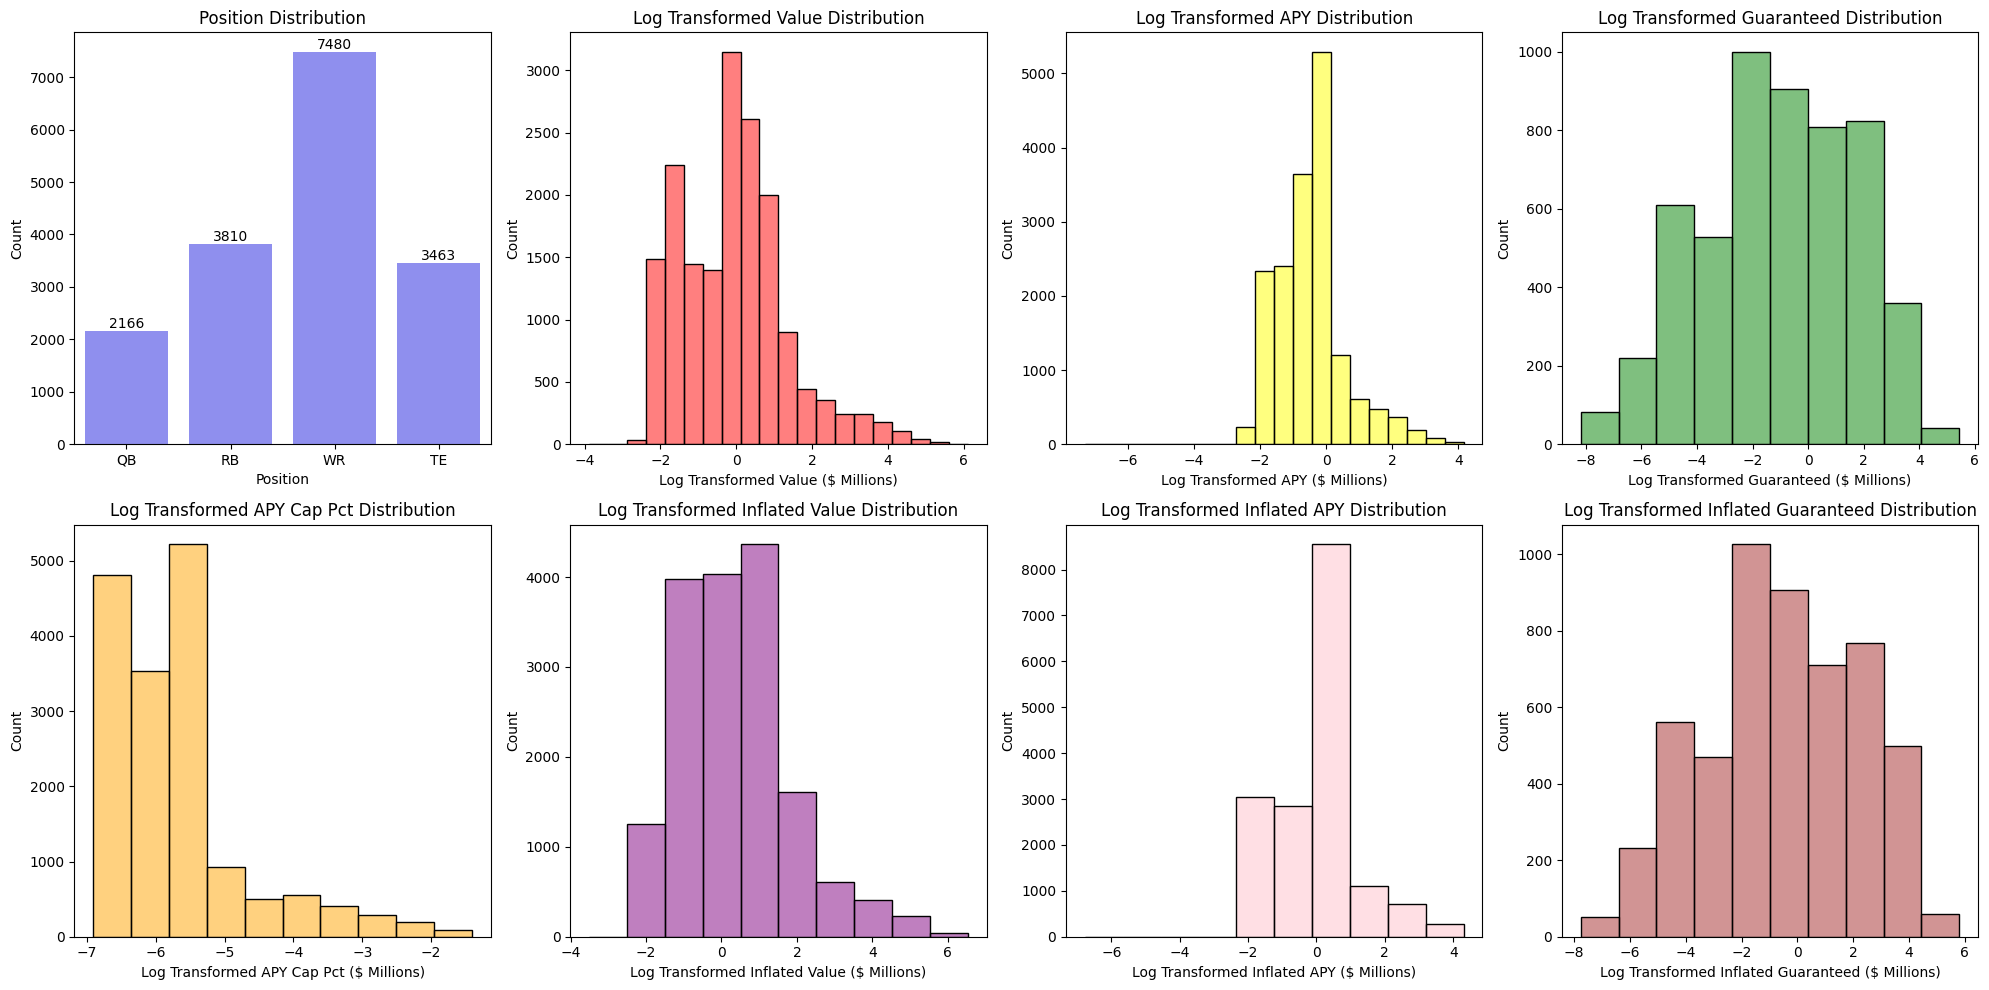

In [209]:
# Log Tranformed Values for Visualizaions
fig, ax = plt.subplots(ncols=4 , nrows=2, figsize=(20,10))
# Counts of position in dataframe
sns.countplot(data = filt_contracts, x = 'position', alpha= 0.5, color = 'blue', ax = ax[0,0])
for container in ax[0,0].containers:
    ax[0,0].bar_label(container)
ax[0,0].set_title('Position Distribution')
ax[0,0].set_xlabel('Position')
ax[0,0].set_ylabel('Count')
# Log Value of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['value']), bins = 20,  alpha= 0.5, color = 'red', ax=ax[0,1])
ax[0,1].set_title('Log Transformed Value Distribution')
ax[0,1].set_xlabel('Log Transformed Value ($ Millions)')
ax[0,1].set_ylabel('Count')
# Log  APY of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['apy']), bins = 20, alpha= 0.5, color = 'yellow', ax=ax[0,2])
ax[0,2].set_title('Log Transformed APY Distribution')
ax[0,2].set_xlabel('Log Transformed APY ($ Millions)')
ax[0,2].set_ylabel('Count')
# Log Guaranteed $ of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['guaranteed']), bins = 10,  alpha= 0.5, color = 'green', ax=ax[0,3])
ax[0,3].set_title('Log Transformed Guaranteed Distribution')
ax[0,3].set_xlabel('Log Transformed Guaranteed ($ Millions)')
ax[0,3].set_ylabel('Count')
# Log APY Cap Percentages of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['apy_cap_pct']), bins = 10,  alpha= 0.5, color = 'orange', ax=ax[1,0])
ax[1,0].set_title('Log Transformed APY Cap Pct Distribution')
ax[1,0].set_xlabel('Log Transformed APY Cap Pct ($ Millions)')
ax[1,0].set_ylabel('Count')
# Log Inflated Values of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['inflated_value']), bins = 10,  alpha= 0.5, color = 'purple', ax=ax[1,1])
ax[1,1].set_title('Log Transformed Inflated Value Distribution')
ax[1,1].set_xlabel('Log Transformed Inflated Value ($ Millions)')
ax[1,1].set_ylabel('Count')
# Log Inflated APY of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['inflated_apy']), bins = 10,  alpha= 0.5, color = 'pink', ax=ax[1,2])
ax[1,2].set_title('Log Transformed Inflated APY Distribution')
ax[1,2].set_xlabel('Log Transformed Inflated APY ($ Millions)')
ax[1,2].set_ylabel('Count')
# Log Inflated Guearanteed $ of Contracts
sns.histplot(data = filt_contracts, x = np.log(filt_contracts['inflated_guaranteed']), bins = 10,  alpha= 0.5, color = 'brown', ax=ax[1,3])
ax[1,3].set_title('Log Transformed Inflated Guaranteed Distribution')
ax[1,3].set_xlabel('Log Transformed Inflated Guaranteed ($ Millions)')
ax[1,3].set_ylabel('Count')
plt.tight_layout()
plt.show()

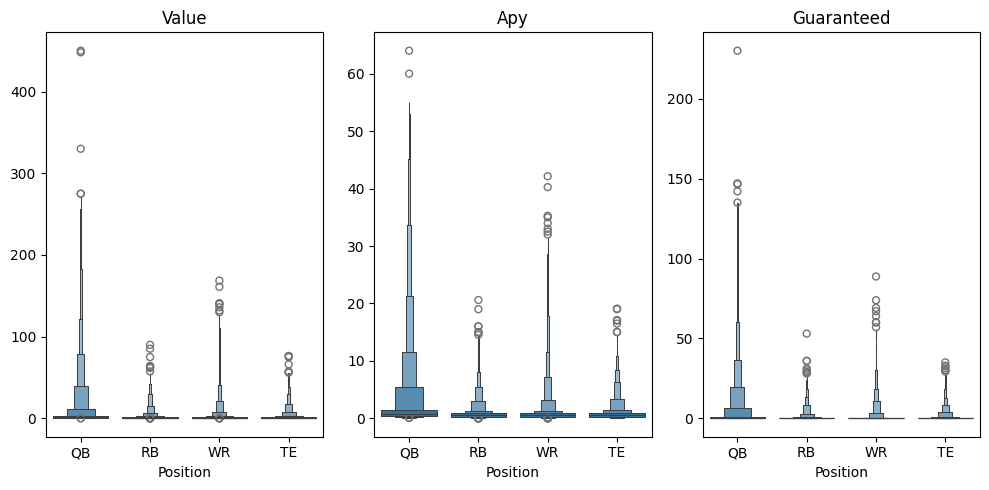

In [210]:
# Contract Features Box plots
# Visualize the differences that occur per position.
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
cols = ['value','apy','guaranteed']
ax = ax.flatten()
for i, col in enumerate(cols):
    sns.boxenplot(x='position', y=col, data=filt_contracts, ax=ax[i])
    ax[i].set_title(col.title())
    ax[i].set_xlabel('Position')
    ax[i].set_ylabel('')
plt.tight_layout()
plt.show()

In [211]:
# Filter out the stats we want to keep, mainly stats and
# features that hold value per the positions selected.
player_stats_to_keep = ['player_id',
                    'player_display_name',
                    'team',
                    'position',
                    'season',
                    'week',
                    'season_type',
                    'completions',
                    'attempts',
                    'passing_yards',
                    'passing_tds',
                    'passing_interceptions',
                    'sacks_suffered',
                    'passing_air_yards',
                    'passing_yards_after_catch',
                    'passing_first_downs',
                    'passing_epa',
                    'carries',
                    'rushing_yards',
                    'rushing_tds',
                    'rushing_fumbles',
                    'rushing_first_downs',
                    'rushing_epa',
                    'receptions',
                    'targets',
                    'receiving_yards',
                    'receiving_tds',
                    'receiving_fumbles',
                    'receiving_air_yards',
                    'receiving_yards_after_catch',
                    'receiving_first_downs',
                    'receiving_epa']
player_stats = filt_player_stats[player_stats_to_keep].copy()

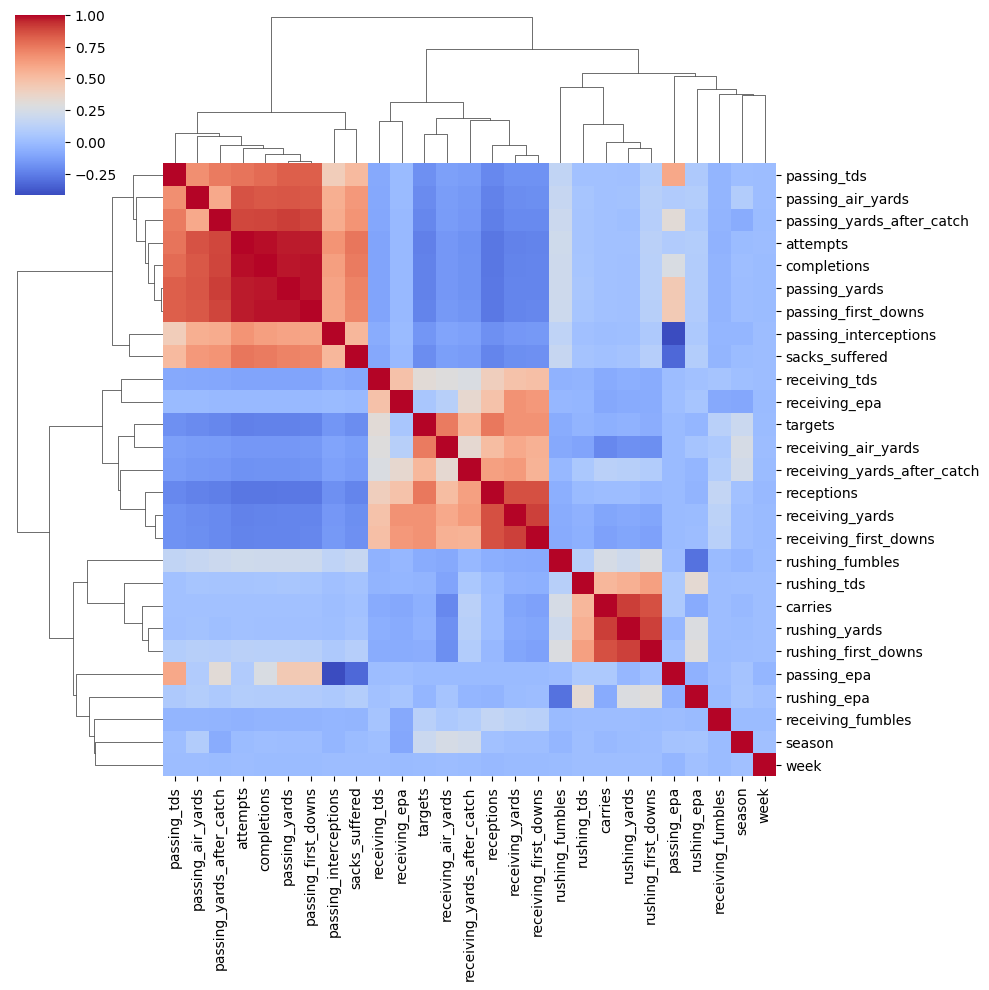

In [212]:
# Creation of a heatmap for understanding feature correlations.
player_corr = player_stats.corr(numeric_only = True)
sns.clustermap(player_corr, cmap= 'coolwarm')
plt.show()

# Data Exploration
We only looked at the raw player stats and raw contracts dataframes as they will be the primary drivers of our model. The other two dataframes will be cleaned in a similar manner to be able to join the data together as needed to improve and test different features when we build our model.

Initial findings point to QB's having the bigger contracts overall, followed by receivers. Runningbacks and tight ends have very similar distributions for contracts overall.
Apart from those findings in the contract data, player stats are aligned with what is expected per position groupings.


# Data Cleaning


In [213]:
# Tracking of 'final' dataframes after all Cleaning of Dataframes.
final_dfs = []

In [214]:
# @title ####Stat Name abbreviation Dictionary Code Block
# Create a dictionary for minimizing stat names in dataframe as well as reverse
# Dictionary to be utilized for extending column names for legebility.
new_stat_names = {'completions': 'cmp',
                'attempts' : 'att',
                'passing_yards': 'p_yds',
                'passing_tds': 'p_tds',
                'passing_interceptions': 'int',
                'sacks_suffered': 'sacked',
                'passing_air_yards' : 'p_airyds',
                'passing_yards_after_catch': 'p_yac',
                'passing_first_downs' : 'p_1sts',
                'passing_epa' : 'p_epa',
                'carries' : 'carr',
                'rushing_yards': 'ru_yds',
                'rushing_tds' : 'ru_tds',
                'rushing_fumbles': 'ru_fumb',
                'rushing_first_downs' : 'ru_1sts',
                'rushing_epa': 'ru_epa',
                'receptions' : 'rec',
                'targets' : 'tgts',
                'receiving_yards' : 'rec_yds',
                'receiving_tds' : 'rec_tds',
                'receiving_fumbles' : 'rec_fumb',
                'receiving_air_yards' : 'rec_airyds',
                'receiving_yards_after_catch': 'rec_yac',
                'receiving_first_downs' : 'rec_1sts',
                'receiving_epa': 'rec_epa'}

# Reverse Dictionary for Stat Abbrevitaions
reverse_stat_dictionary = {v: k for k, v in new_stat_names.items()}

In [215]:
# @title ####Player Stats Data Cleaning Code Block

# Re-layout the list of the columns pertaining to Offensive metrics
player_stats_to_keep = ['player_id',
                    'player_display_name',
                    'team',
                    'position',
                    'season',
                    'week',
                    'season_type',
                    'completions',
                    'attempts',
                    'passing_yards',
                    'passing_tds',
                    'passing_interceptions',
                    'sacks_suffered',
                    'passing_air_yards',
                    'passing_yards_after_catch',
                    'passing_first_downs',
                    'passing_epa',
                    'carries',
                    'rushing_yards',
                    'rushing_tds',
                    'rushing_fumbles',
                    'rushing_first_downs',
                    'rushing_epa',
                    'receptions',
                    'targets',
                    'receiving_yards',
                    'receiving_tds',
                    'receiving_fumbles',
                    'receiving_air_yards',
                    'receiving_yards_after_catch',
                    'receiving_first_downs',
                    'receiving_epa']

# Create new DF that only includes the offensive metrics.
off_player_stats = filt_player_stats[player_stats_to_keep].copy()

# Rename columns to abbrevited form.
off_player_stats.rename(columns=new_stat_names, inplace=True)

# Create groups for columns in the data, seperating identifying data from statistical data.
id_cols = ['player_id','player_name','player_display_name','team','position','season_type','season','week']

# Isolate remainder of columns for calculation of season totals per player.
stats_cols = [
    c for c in off_player_stats.columns if c not in id_cols
]

# Grouping for player stats cleaning.
p_group = ['player_id','season','team']

# Create DataFrame for Total Season Stats
# Group the dataframe by group defined above and sum all stats.
tot_stats = off_player_stats.groupby(p_group)[stats_cols].sum().add_suffix('_tot')

# Create Dataframe with Player Name, Position and total games played
t = off_player_stats.groupby(p_group).agg(
    player = ('player_display_name', 'first'),
    position = ('position', 'first'),
    gp_tot=('season_type', 'count'),
)
# Combine Newly created Dataframe with total stats accumulation
tot_plyr_sts = t.join(tot_stats).reset_index()

#Fill Empty entries with 0
tot_plyr_sts = tot_plyr_sts.fillna(0)

# Clean up Dtypes for Dataframe
tot_ply_sts = tot_plyr_sts.convert_dtypes()

# Add Dataframe to final_dfs tracking
final_dfs.append('tot_plyr_sts')


In [216]:
# @title ####Contract Data Cleaning Code Block


# Identify which columns are significant to keep.
contracts_cols_to_keep = ['player',
                          'position',
                          'team',
                          'year_signed',
                          'years',
                          'value',
                          'apy',
                          'guaranteed',
                          'apy_cap_pct',
                          'draft_year',
                          'draft_team'
                          ]

# Filter out columns of interest
contracts_filtered = filt_contracts[contracts_cols_to_keep].copy()

# Replace year_signed values that are 0 with draft year, given rookie contract start.
contracts_filtered['year_signed'] = np.where(contracts_filtered['year_signed'] == 0, contracts_filtered['draft_year'], contracts_filtered['year_signed'])

# Drop any entries where no information about year_signed or draft year.
contracts_filtered = contracts_filtered.dropna(subset=['year_signed','draft_year'])

# Drop any entries where draft year is ahead of year signed (repeated name for younger players)
contracts_filtered = contracts_filtered[contracts_filtered['year_signed'] >= contracts_filtered['draft_year']]

# Filter data to remove multiple contracts within the same year, data includes
# players released and re-signed in same season. Keeping only most recent
# contract.
contracts_filtered = contracts_filtered.sort_index().drop_duplicates(['player','year_signed'], keep = 'last')

# Filling years null values with 1, assuming minimum 1 year deal.
contracts_filtered['years'] = contracts_filtered['years'].fillna(1)

# Added a new column for contract type between
# rookie and veteran
contracts_filtered['contract_type'] = np.where(contracts_filtered['year_signed'] == contracts_filtered['draft_year'],'rookie','veteran')
contracts_filtered['exp'] = contracts_filtered['year_signed'] -  contracts_filtered['draft_year']

# Sorting contracts data based on player and year signed
tracked_contracts = contracts_filtered.sort_values(['player','year_signed'])

# Created new column tracking previous team for contract type purposes
# Rookie contracts are not given due to performance, but by draft position.
tracked_contracts['prev_team'] = np.where(tracked_contracts['contract_type'] == 'veteran', tracked_contracts.groupby('player')['team'].shift(1), tracked_contracts['team'])

# Establishing conditions and choices for new contract_event column which will be the basis of our final data set.
contract_conditions = [
    (tracked_contracts['contract_type'] == 'rookie'),
    (tracked_contracts['contract_type'] == 'veteran') & (tracked_contracts['team'] == tracked_contracts['prev_team']),
    (tracked_contracts['contract_type'] == 'veteran') & (tracked_contracts['team'] != tracked_contracts['prev_team'])
]
# Different contract types
contract_choices = ['rookie_deal', 'extension', 'new_team_signing' ]
tracked_contracts['contract_event'] = np.select(contract_conditions,contract_choices, default = 'unknown')

# Dropping players that do not have a previous team. No previous teams implies
# undrafted Free Agents with no stats leading to contract.
tracked_contracts = tracked_contracts.dropna(subset=['prev_team'])

# Filter Dataframe for contracts to keep only players that joined league after 2000
# to avoid missing data from previous seasons.
contract_final = tracked_contracts[tracked_contracts['draft_year'] > 2000].copy().reset_index(drop=True)

# Creating Contract ID column to differentiate different contracts for same player
contract_final['contract_id'] = contract_final.index + 1

# Clean up the dataframe converting floats to ints where needed.
contract_final = contract_final.convert_dtypes()

# Adding dataframe to final_dfs tracking
final_dfs.append('contract_final')


In [217]:
# Similar steps from player_stats completed to the team_stats.
# Look at all the columns for the team stats dataframe.
print(f'Team stats columns are as follows :')
quart = len(raw_team_stats.columns) // 10
for i , col in enumerate(raw_team_stats.columns):
  if i % quart == 0:
    print()
  print(col, end = ' / ')

Team stats columns are as follows :

season / week / team / season_type / opponent_team / completions / attempts / passing_yards / passing_tds / passing_interceptions / 
sacks_suffered / sack_yards_lost / sack_fumbles / sack_fumbles_lost / passing_air_yards / passing_yards_after_catch / passing_first_downs / passing_epa / passing_cpoe / passing_2pt_conversions / 
carries / rushing_yards / rushing_tds / rushing_fumbles / rushing_fumbles_lost / rushing_first_downs / rushing_epa / rushing_2pt_conversions / receptions / targets / 
receiving_yards / receiving_tds / receiving_fumbles / receiving_fumbles_lost / receiving_air_yards / receiving_yards_after_catch / receiving_first_downs / receiving_epa / receiving_2pt_conversions / special_teams_tds / 
def_tackles_solo / def_tackles_with_assist / def_tackle_assists / def_tackles_for_loss / def_tackles_for_loss_yards / def_fumbles_forced / def_sacks / def_sack_yards / def_qb_hits / def_interceptions / 
def_interception_yards / def_pass_defended /

In [262]:
# @title ####Season Stats Data Cleaning Code Block
# We want to create a list of the columns important to keep.
# Mainly those matching columns kept in Player stats.
season_stats_to_keep = ['season',
 'week',
 'team',
 'season_type',
 'completions',
 'attempts',
 'passing_yards',
 'passing_tds',
 'passing_interceptions',
 'sacks_suffered',
 'passing_air_yards',
 'passing_yards_after_catch',
 'passing_first_downs',
 'passing_epa',
 'carries',
 'rushing_yards',
 'rushing_tds',
 'rushing_fumbles',
 'rushing_first_downs',
 'rushing_epa',
 'receptions',
 'targets',
 'receiving_yards',
 'receiving_tds',
 'receiving_fumbles',
 'receiving_air_yards',
 'receiving_yards_after_catch',
 'receiving_first_downs',
 'receiving_epa'
]

# Filter out to only include the columns of interest and abbreviate column names
team_stats = raw_team_stats[season_stats_to_keep].copy()
season_stats = team_stats.rename(columns=new_stat_names)

# Seperate the identifier columns into a list
id_cols = ['season','week','season_type','team']

# Create a list of the remaining statistic columns
stat_cols = [ c for c in season_stats.columns if c not in id_cols]

# Create DataFrame for Total Season Stats
# Sum up all stats of each team every season.
sum_stats = season_stats.groupby(['team','season'])[stats_cols].sum().add_suffix('_tot')
# Establish new Datframe with Gamesplayed (assuming full season)
te = season_stats.groupby(['team','season']).agg(
    gp_tot=('season_type', 'count'),
)
# Join two dataframes together
tot_tm_sts = te.join(sum_stats).reset_index()

# Fill any empty stat with 0
tot_tm_sts = tot_tm_sts.fillna(0)

# Clean up Dtypes for Dataframe
tot_tm_sts = tot_tm_sts.convert_dtypes()

# Add to final_df tracker
final_dfs.append('tot_tm_sts')


In [263]:
season_stats

,season,week,team,season_type,cmp,att,p_yds,p_tds,int,sacked,p_airyds,p_yac,p_1sts,p_epa,carr,ru_yds,ru_tds,ru_fumb,ru_1sts,ru_epa,rec,tgts,rec_yds,rec_tds,rec_fumb,rec_airyds,rec_yac,rec_1sts,rec_epa
0,2000,1,ARI,REG,28,49,318,2,3,1,12,318,15,1.011349,20,43,0,1,4,-6.913380,28,47,318,2,0,12,0,15,2.382013
1,2000,1,ATL,REG,16,31,264,2,0,0,0,264,13,10.218793,32,95,0,2,6,-11.639264,16,30,264,2,0,0,0,13,10.346253
2,2000,1,BAL,REG,18,32,199,1,0,1,0,199,9,2.892977,36,140,0,0,9,-0.812932,18,30,199,1,0,0,0,9,5.271726
3,2000,1,BUF,REG,13,26,174,1,0,5,0,174,9,-4.197206,35,129,0,0,6,-10.088240,13,24,174,1,0,0,0,9,2.890964
4,2000,1,CAR,REG,17,26,183,1,0,6,0,183,6,-3.202182,20,112,0,0,4,-0.356698,17,25,183,1,0,0,0,6,6.882382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14009,2025,21,LA,POST,22,35,374,3,0,1,430,124,17,16.168382,22,114,0,0,7,1.988256,22,34,374,3,1,430,124,17,18.225684
14010,2025,21,NE,POST,10,21,86,0,0,5,252,37,2,-10.908902,38,141,1,0,10,1.089954,10,20,86,0,0,252,37,2,-2.253673
14011,2025,21,SEA,POST,25,36,346,3,0,3,296,146,19,18.021386,26,75,1,1,5,-5.144103,25,34,346,3,1,296,146,19,23.744889
14012,2025,22,NE,POST,27,43,295,2,2,6,460,129,14,-21.479019,18,79,0,0,2,0.753927,27,41,295,2,0,460,129,14,-7.967787


In [219]:
# Look at Columns to help identify data of interest.
print(f'Schedules columns are as follows :')
quart = len(raw_schedules.columns) // 5
for i , col in enumerate(raw_schedules.columns):
  if i % quart == 0:
    print()
  print(col, end = ' / ')

Schedules columns are as follows :

game_id / season / game_type / week / gameday / weekday / gametime / away_team / away_score / 
home_team / home_score / location / result / total / overtime / old_game_id / gsis / nfl_detail_id / 
pfr / pff / espn / ftn / away_rest / home_rest / away_moneyline / home_moneyline / spread_line / 
away_spread_odds / home_spread_odds / total_line / under_odds / over_odds / div_game / roof / surface / temp / 
wind / away_qb_id / home_qb_id / away_qb_name / home_qb_name / away_coach / home_coach / referee / stadium_id / 
stadium / 

In [220]:
# @title ####Schedule Data Cleaning Code Block
# # Goal from this Dataframe is to establish eachs teams and QBs W/L records
# Create a list of columns we are interested in
schedule_cols_to_keep = ['season','game_type','week', 'away_score','away_team', 'home_score','home_team','away_qb_name', 'home_qb_name']
results = raw_schedules[schedule_cols_to_keep].copy()

# Create new columns where we identify the winning and losing QB/teams for each game entry
results['winning_qb'] = np.where(results['away_score'] > results['home_score'] , results['away_qb_name'], results['home_qb_name'])
results['winning_team'] = np.where(results['away_score'] > results['home_score'] , results['away_team'], results['home_team'])
results['losing_qb'] = np.where(results['away_score'] < results['home_score'] , results['away_qb_name'], results['home_qb_name'])
results['losing_team'] = np.where(results['away_score'] < results['home_score'] , results['away_team'], results['home_team'])

# After re-labeling data from each column for our intended use, drop unneccesary columns
qb_data = results.drop(columns=['away_score','away_team','home_score','home_team','away_qb_name','home_qb_name'])

# Create new Data Frames that seperates and labels the results for each game as its own entry given each QB in that week.
# Wins and losses dataframes
temp = qb_data.copy()
wins = temp.assign(player = temp['winning_qb'], team = temp['winning_team'], result = 'W')[['player','team','season','week','game_type','result']]
losses = temp.assign(player = temp['losing_qb'], team = temp['losing_team'], result = 'L')[['player','team','season','week','game_type','result']]

# combine the newly created DataFrame so all data can be aggregated .
combined = pd.concat([wins,losses], ignore_index=True)

## Aggregation for QB and Team records
# QB Records are a reflection of games the player started
qbgroup = ['player','season','team']
team_group = ['team','season']

# Create new Dataframes aggregating wins and losses per grouping, also adding gp count.
tot_qb_rcds = combined.groupby(qbgroup).agg(
    w=('result', lambda x: (x == 'W').sum()),
    l=('result', lambda x: (x == 'L').sum()),
    gp=('result', 'count')).add_suffix('_tot').reset_index()

tot_tm_rcds = combined.groupby(team_group).agg(
    w=('result', lambda x: (x == 'W').sum()),
    l=('result', lambda x: (x == 'L').sum()),
    gp=('result', 'count')).add_suffix('_tot').reset_index()

# Adding both to final_dfs tracking
final_dfs.append('tot_qb_rcds')
final_dfs.append('tot_tm_rcds')



# Post Cleaning Data Analysis
After going through all datasets and cleaning up for our purposes, we will revisit all to visualize how it has altered. We should not expect to see much difference aside from totals being accumulated vs the week by week values prior.

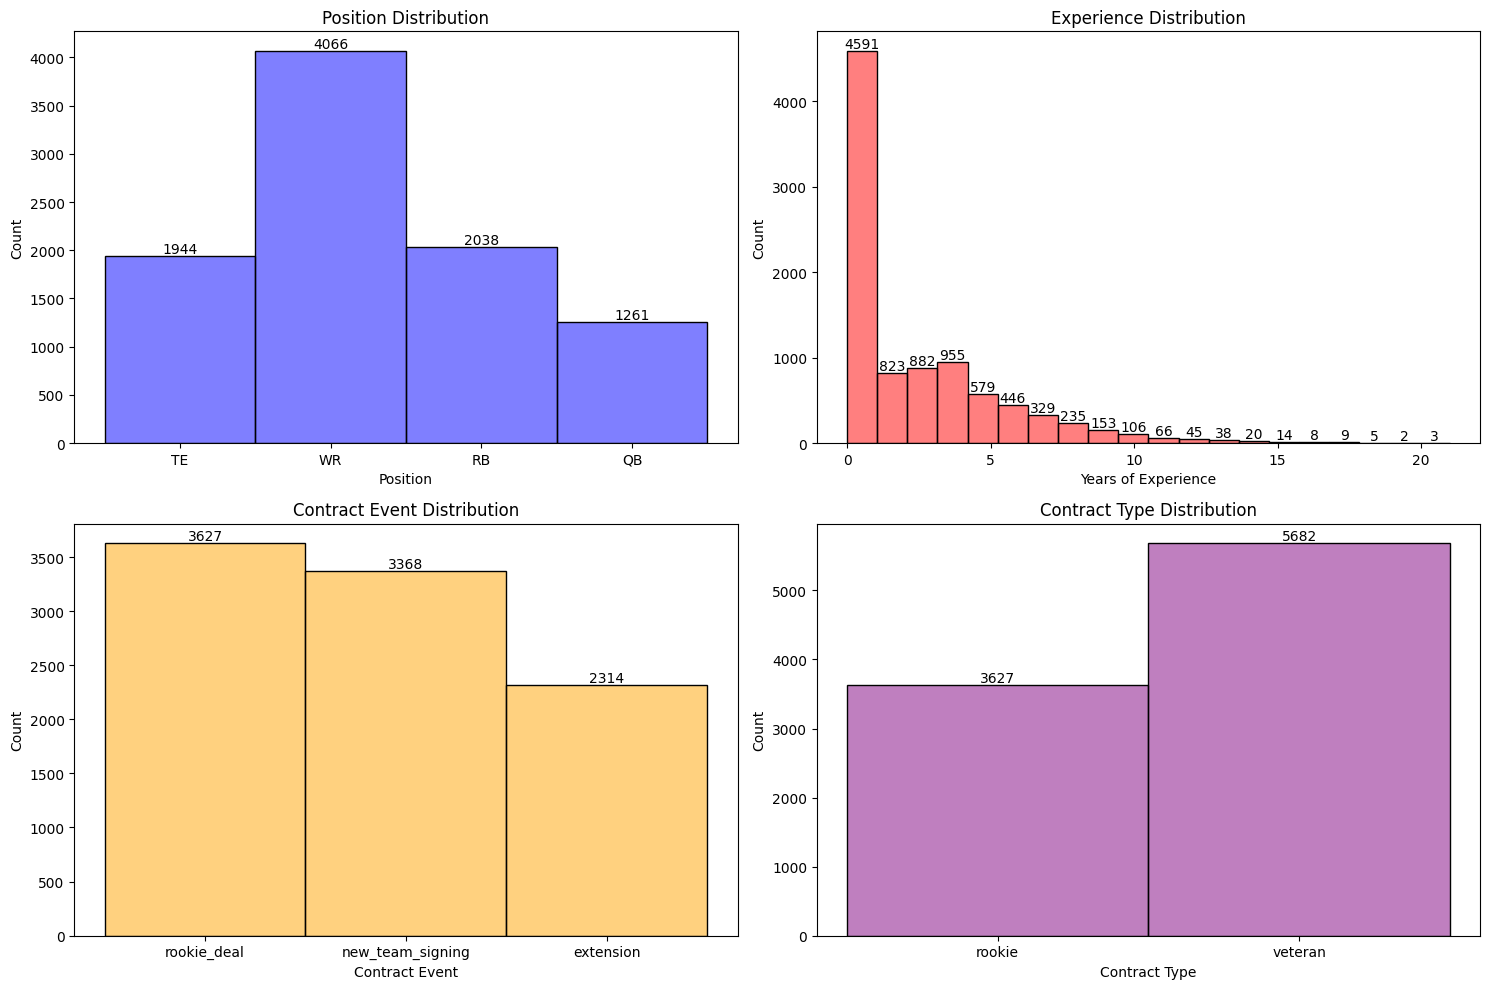

In [221]:
#====================================
# Contract Data Counts
#====================================
fig , ax = plt.subplots(nrows=2, ncols=2, figsize=(15,10))
# Counts of contracts per position
sns.histplot(data = contract_final, x = 'position', bins = 20, alpha= 0.5, color = 'blue', ax = ax[0,0])
ax[0,0].set_title('Position Distribution')
ax[0,0].set_xlabel('Position')
ax[0,0].set_ylabel('Count')
for container in ax[0,0].containers:
    ax[0,0].bar_label(container)
# Distribution of experiences of players
sns.histplot(data = contract_final, x = 'exp', bins = 20, alpha= 0.5, color = 'red', ax=ax[0,1])
ax[0,1].set_title('Experience Distribution')
ax[0,1].set_xlabel('Years of Experience')
ax[0,1].set_ylabel('Count')
for container in ax[0,1].containers:
    ax[0,1].bar_label(container)
# Distribution of contract events created.
sns.histplot(data = contract_final, x = 'contract_event', bins = 20, alpha= 0.5, color = 'orange', ax=ax[1,0])
ax[1,0].set_title('Contract Event Distribution')
ax[1,0].set_xlabel('Contract Event')
ax[1,0].set_ylabel('Count')
for container in ax[1,0].containers:
    ax[1,0].bar_label(container)
# Distribution of contract types
sns.histplot(data = contract_final, x = 'contract_type', bins = 20, alpha= 0.5, color = 'purple', ax=ax[1,1])
ax[1,1].set_title('Contract Type Distribution')
ax[1,1].set_xlabel('Contract Type')
ax[1,1].set_ylabel('Count')
for container in ax[1,1].containers:
    ax[1,1].bar_label(container)
plt.tight_layout()
plt.show()

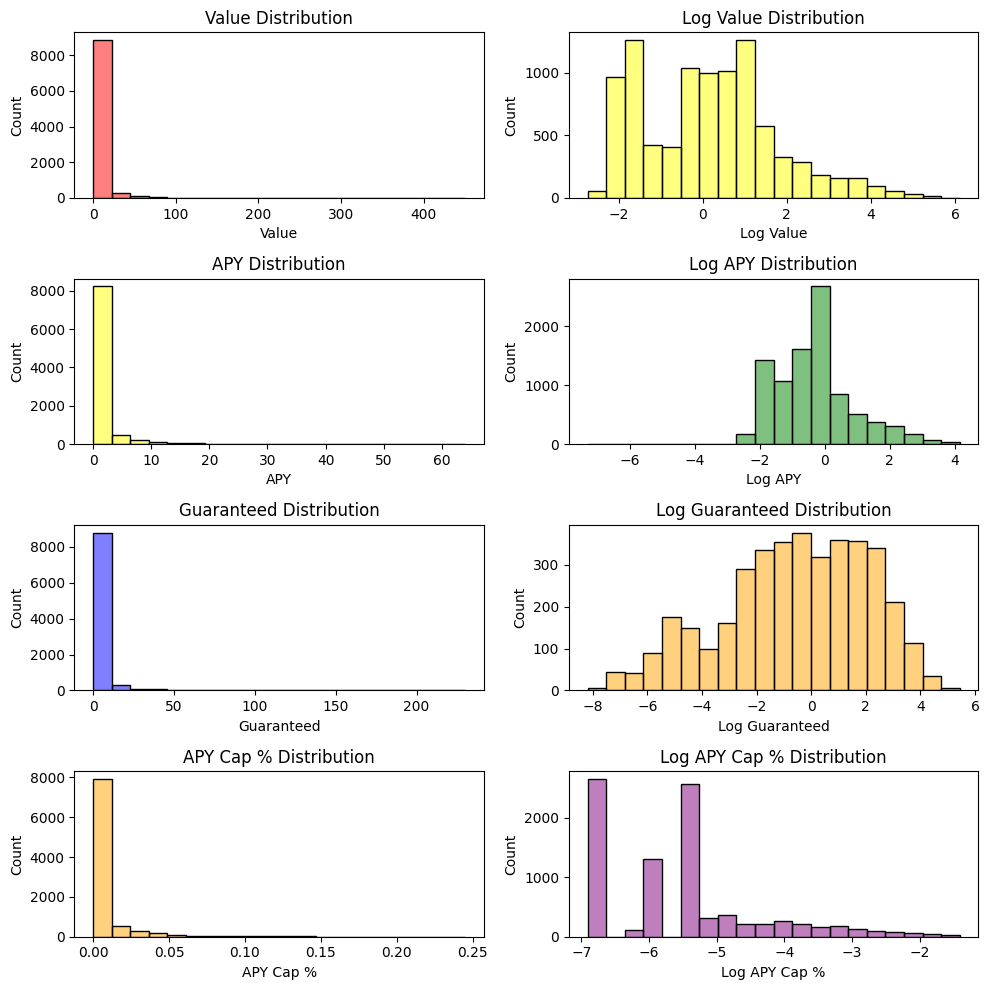

In [222]:
#====================================
# Contract Data Counts
#====================================
fig, ax = plt.subplots(4 , 2, figsize=(10,10))
sns.histplot(data = contract_final, x = 'value', bins = 20, alpha= 0.5, color = 'red', ax=ax[0,0])
ax[0,0].set_title('Value Distribution')
ax[0,0].set_xlabel('Value')
ax[0,0].set_ylabel('Count')
sns.histplot(data = contract_final, x = np.log(contract_final['value']) , bins = 20, alpha= 0.5, color = 'yellow', ax=ax[0,1])
ax[0,1].set_title('Log Value Distribution')
ax[0,1].set_xlabel('Log Value')
ax[0,1].set_ylabel('Count')
sns.histplot(data = contract_final, x = 'apy', bins = 20, alpha= 0.5, color = 'yellow', ax=ax[1,0])
ax[1,0].set_title('APY Distribution')
ax[1,0].set_xlabel('APY')
ax[1,0].set_ylabel('Count')
sns.histplot(data = contract_final, x = np.log(contract_final['apy']) , bins = 20, alpha= 0.5, color = 'green', ax=ax[1,1])
ax[1,1].set_title('Log APY Distribution')
ax[1,1].set_xlabel('Log APY')
ax[1,1].set_ylabel('Count')
sns.histplot(data = contract_final, x = 'guaranteed', bins = 20, alpha= 0.5, color = 'blue', ax=ax[2,0])
ax[2,0].set_title('Guaranteed Distribution')
ax[2,0].set_xlabel('Guaranteed')
ax[2,0].set_ylabel('Count')
sns.histplot(data = contract_final, x = np.log(contract_final['guaranteed']) , bins = 20, alpha= 0.5, color = 'orange', ax=ax[2,1])
ax[2,1].set_title('Log Guaranteed Distribution')
ax[2,1].set_xlabel('Log Guaranteed')
ax[2,1].set_ylabel('Count')
sns.histplot(data = contract_final, x = 'apy_cap_pct', bins = 20, alpha= 0.5, color = 'orange', ax=ax[3,0])
ax[3,0].set_title('APY Cap % Distribution')
ax[3,0].set_xlabel('APY Cap %')
ax[3,0].set_ylabel('Count')
sns.histplot(data = contract_final, x = np.log(contract_final['apy_cap_pct']), bins = 20, alpha= 0.5, color = 'purple', ax=ax[3,1])
ax[3,1].set_title('Log APY Cap % Distribution')
ax[3,1].set_xlabel('Log APY Cap %')
ax[3,1].set_ylabel('Count')
plt.tight_layout()
plt.show()

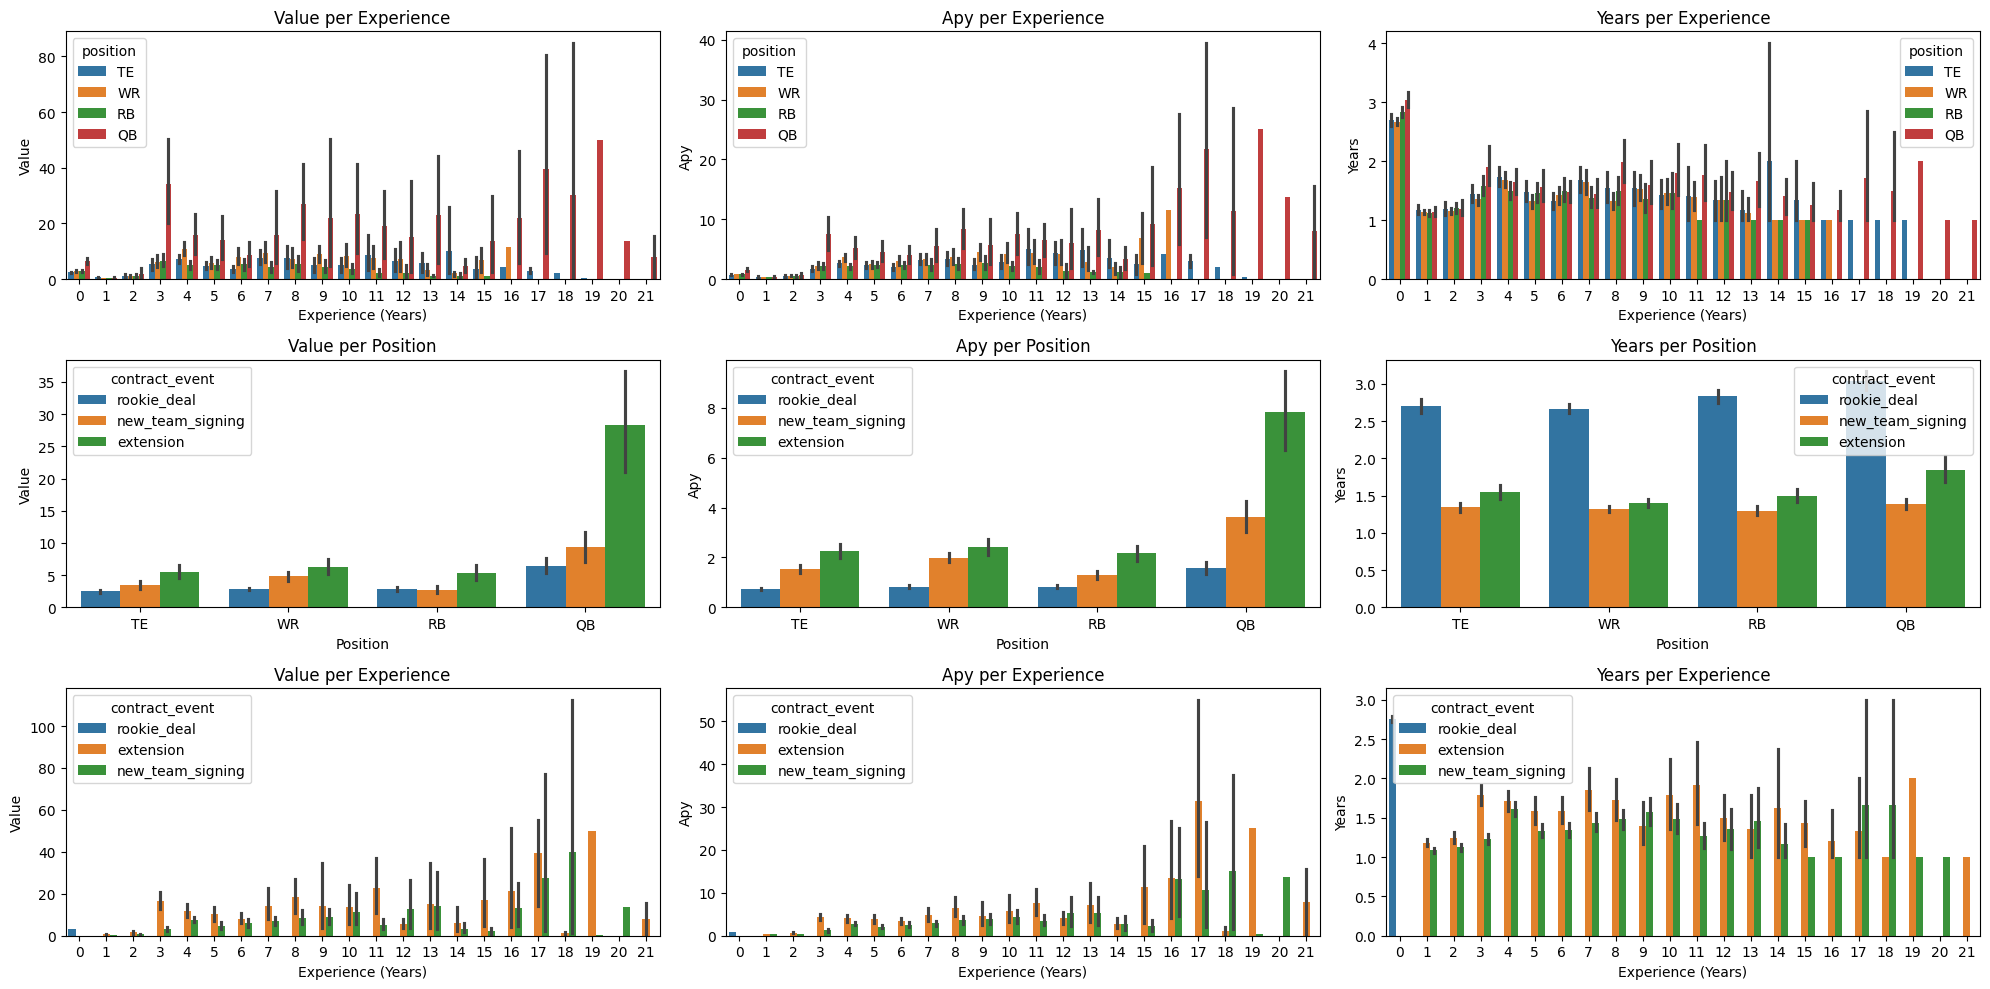

In [223]:
# Contract Features Box and Bar plots for Key Contract Values
# Per experience/position seperated by position and contract_events
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 10))
cols = ['value','apy','years']
for i, col in enumerate(cols):
    sns.barplot(x='exp', y=col, hue = 'position', data=contract_final, ax=ax[0,i])
    ax[0,i].set_title(f'{col.title()} per Experience')
    ax[0,i].set_xlabel('Experience (Years)')
    ax[0,i].set_ylabel(col.title())
    sns.barplot(x='position', y=col, hue = 'contract_event', data=contract_final, ax=ax[1,i])
    ax[1,i].set_title(f'{col.title()} per Position')
    ax[1,i].set_xlabel('Position')
    ax[1,i].set_ylabel(col.title())
    sns.barplot(x='exp', y=col, hue = 'contract_event', data=contract_final, ax=ax[2,i])
    ax[2,i].set_title(f'{col.title()} per Experience')
    ax[2,i].set_xlabel('Experience (Years)')
    ax[2,i].set_ylabel(col.title())
plt.tight_layout()

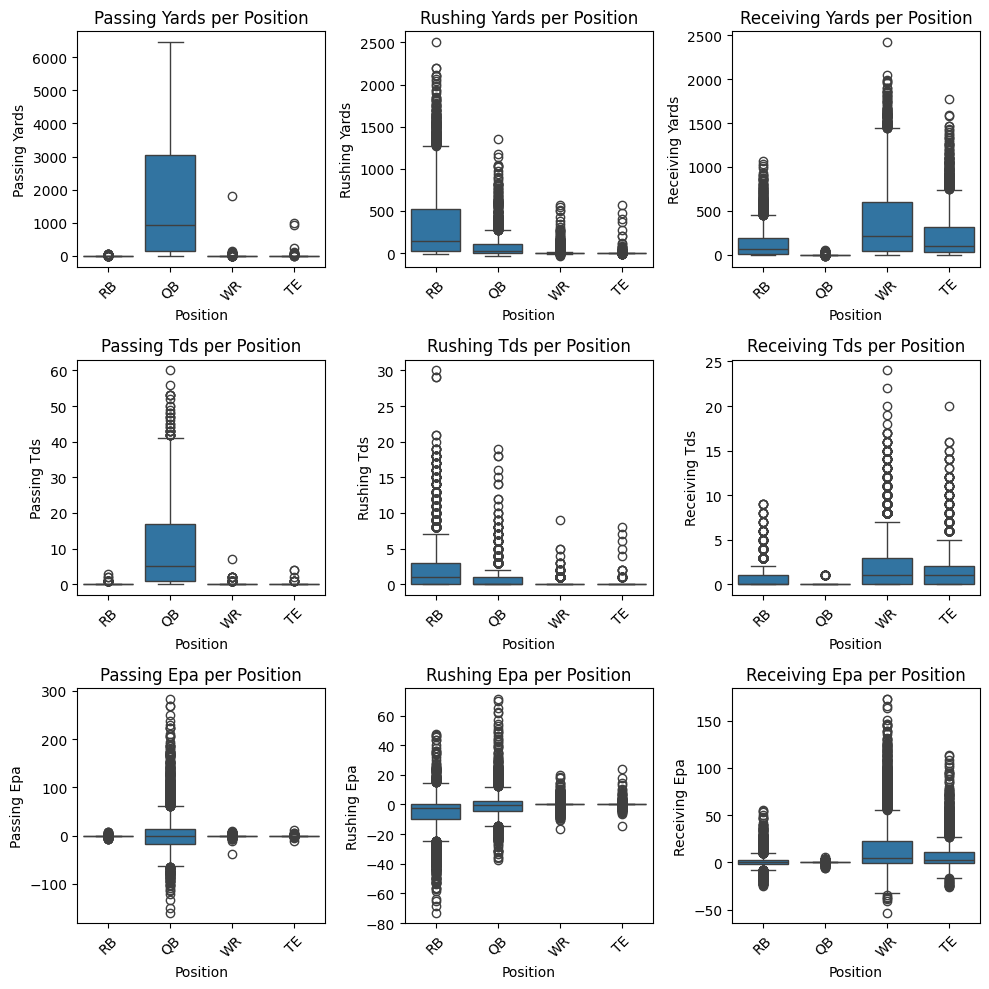

In [224]:
#====================================
# Player Stats Data - Whole Season
#====================================
# Looking over all Key stat total distributions per position
# following all season aggregations.
stats = ('_yds','_tds','_epa')
s_type = ('p_','ru_','rec')
prurec_ydstds = []
for stat in stats:
  matched = [col for col in tot_plyr_sts.columns
             if stat in col
             and col.startswith(s_type)]
  prurec_ydstds.extend(matched)

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
ax = ax.flatten()
for i, col in enumerate(prurec_ydstds):
  label = col.replace('_tot', '')
  sns.boxplot(x='position', y=col, data=tot_plyr_sts, ax=ax[i])
  ax[i].set_title(f'{reverse_stat_dictionary[label].replace("_"," ").title()} per Position')
  ax[i].set_xlabel('Position')
  ax[i].set_ylabel(reverse_stat_dictionary[label].replace("_"," ").title())
  ax[i].tick_params(rotation=45, axis = 'x')
plt.tight_layout()
plt.show()

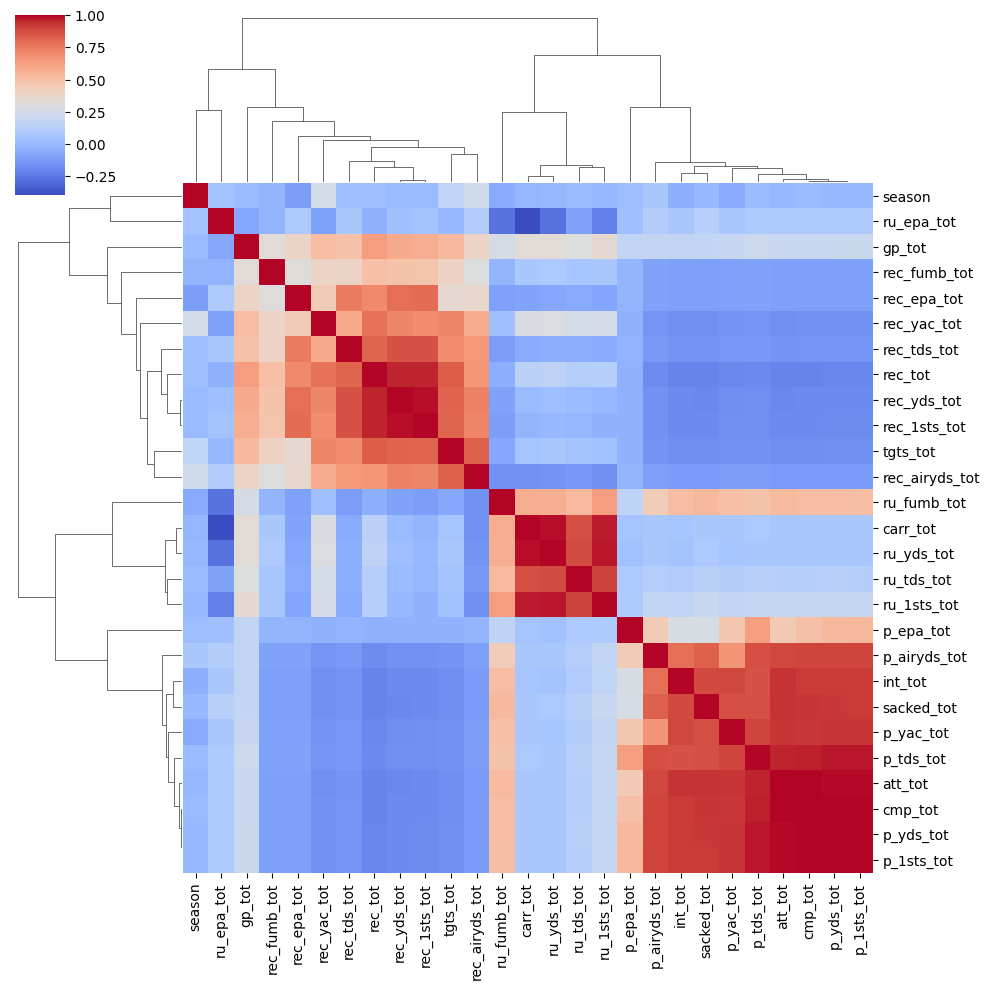

In [225]:
# Creation of a Heatmap for Player stats.
plyr_corr = tot_plyr_sts.corr(numeric_only = True)
sns.clustermap(plyr_corr, cmap='coolwarm')

# Post Cleaning Findings
After looking at our cleaned Datasets, we come to realize that player specific stats are significant to consider on a position by position basis.  

We will look to build a base model for all players combined, as well as differentiating them per position and key stat groupings.  
Ultimately, we will look at understanding key features for each and which may or may not overlap between models.  

It would also prove beneficial to see how each metrics group relates to our ultimate target of APY contract value.

# Initial Data Formation
We will now look to group contract and player stats data, while also throwing in the team records. This will be the first data that will be utilized for modeling.

In [226]:
# Merging Total Player Sats and Team Records to See win/loss impact on APY/Value
# of Contract
tot_plyr_sts_rcds = pd.merge(tot_plyr_sts,tot_tm_rcds, on=['team','season'], how='left', suffixes=('_plyr','_tm'))
final_dfs.append('tot_plyr_sts_rcds')

In [227]:
# Create Dataframe with subset of data.
contract_subset = contract_final[['player','position','team','exp','year_signed','value','apy','contract_event','draft_year','contract_id']].copy()

# Inner merge contract subset with player stats and records
# This will create a new Dataframe where each contract event will have all the stats available
# for each player.
merged = tot_plyr_sts_rcds.merge(contract_subset, on = ['player','position'], how = 'inner')

# Filter the data for player stats prior to the year contract was signed,
# removing stats during or after contracts.
merged = merged[merged['year_signed'] > merged['season']]

# Filter out older players who have names that match recent players
merged = merged[merged['season'] >= merged['draft_year']]

# Define the desired order of columns explicitly
start_cols = ['player', 'position', 'season', 'team_x']
contract_info_cols = ['team_y','year_signed','exp', 'value','apy','contract_event', 'draft_year', 'contract_id']

# Get all other columns, excluding those already in start_cols or contract_info_cols
remaining_cols = [col for col in merged.columns if col not in (set(start_cols) | set(contract_info_cols))]

# Assemble the new column order
col_swap = start_cols + contract_info_cols + remaining_cols

# Establish new DF
contracts_w_stats = merged[col_swap]

# Add to final_df tracker
final_dfs.append('contracts_w_stats')

In [228]:
# Seperate Columns between id/ stats
id_cols = ['player_id', 'player','position','season','team']
stat_cols = [
    col for col in tot_plyr_sts_rcds.columns if col not in id_cols
]

# Establish all Aggregations to be used for baseline models.
# We are using differnt forms for all stats leading up to a contract year.
all_aggregations = {
    col: ['sum','mean','max']
    for col in stat_cols
}
# Also use specific addition and average metrics leading up to contract event.
sum_agg = {col: 'sum' for col in stat_cols}
mean_agg = {col: 'mean' for col in stat_cols}

# Create Dataframes given all of the aggregations.
sum_agg = contracts_w_stats.groupby('contract_id').agg(sum_agg)
mean_agg = contracts_w_stats.groupby('contract_id').agg(mean_agg)
all_agg = (contracts_w_stats.groupby('contract_id').agg(all_aggregations))

# Merge the data frames with the original contracts data frame on contract_id.
# Giving us all aggregations of stats prior to each contract event.
sum_agg.reset_index()
contract_sts_sum = contract_final.merge(sum_agg, on='contract_id', how='inner')

mean_agg = mean_agg.reset_index()
contract_sts_mean = contract_final.merge(mean_agg, on='contract_id', how='inner')

all_agg.columns = [f'{col[0]}_{col[1]}' for col in all_agg.columns]
all_agg = all_agg.reset_index()
contract_sts_agg = pd.merge(contract_final, all_agg, on='contract_id', how='inner')

# Removing unnecessary ID columns. Potential targets identified.
id_cols_drp =['player','team','year_signed','draft_year','years','value', 'guaranteed', 'apy_cap_pct','draft_team','contract_type','prev_team','contract_id']

# Drop Unwanted Columns.
cntrct_sum = contract_sts_sum.drop(columns=id_cols_drp)
cntrct_mean = contract_sts_mean.drop(columns=id_cols_drp)
cntrct_agg = contract_sts_agg.drop(columns=id_cols_drp)

In [229]:
# Create dataframes that are specific to each position.
# QB's
qb_agg = cntrct_agg[cntrct_agg['position'] == 'QB'].drop(columns=['position'])
qb_sum = cntrct_sum[cntrct_sum['position'] == 'QB'].drop(columns=['position'])
qb_mean = cntrct_mean[cntrct_mean['position'] == 'QB'].drop(columns=['position'])
# RB's
rb_agg = cntrct_agg[cntrct_agg['position'] == 'RB'].drop(columns=['position'])
rb_sum = cntrct_sum[cntrct_sum['position'] == 'RB'].drop(columns=['position'])
rb_mean = cntrct_mean[cntrct_mean['position'] == 'RB'].drop(columns=['position'])
# WR's
wr_agg = cntrct_agg[cntrct_agg['position'] == 'WR'].drop(columns=['position'])
wr_sum = cntrct_sum[cntrct_sum['position'] == 'WR'].drop(columns=['position'])
wr_mean = cntrct_mean[cntrct_mean['position'] == 'WR'].drop(columns=['position'])
# TE's
te_agg = cntrct_agg[cntrct_agg['position'] == 'TE'].drop(columns=['position'])
te_sum = cntrct_sum[cntrct_sum['position'] == 'TE'].drop(columns=['position'])
te_mean = cntrct_mean[cntrct_mean['position'] == 'TE'].drop(columns=['position'])

In [230]:
# Estbalish Stats Groupings
stat_groups = {
    'passing': [
        'att',
        'cmp',
        'p_yds',
        'p_tds',
        'int',
        'sacked',
        'p_airyds',
        'p_yac',
        'p_1sts',
        'p_epa'
    ],
    'rushing': [
        'carr',
        'ru_yds',
        'ru_tds',
        'ru_fumb',
        'ru_1sts',
        'ru_epa'
    ],
    'receiving': [
        'rec',
        'tgts',
        'rec_yds',
        'rec_tds',
        'rec_fumb',
        'rec_airyds',
        'rec_yac',
        'rec_1sts',
        'rec_epa'
    ],
    'epas' : [
        'p_epa',
        'ru_epa',
        'rec_epa'
    ],
    'tds' : [
        'p_tds',
        'ru_tds',
        'rec_tds'
    ],
    'yds' : [
        'p_yds',
        'ru_yds',
        'rec_yds'
    ]
}

In [231]:
## Function for plotting regplots for data given features.
import math
def regplot_array(data,features, color= None):
 n_cols = 4
 n_rows = math.ceil(len(features) / n_cols)
 fig, ax = plt.subplots(
      n_rows,
      n_cols,
      figsize=(5 * n_cols, 4 * n_rows)
  )
 ax = ax.flatten()
 for i, col in enumerate(features):
    col_name = f'{col}_tot'
    sns.regplot(data=data, x=col_name, y='apy', ax=ax[i], color = color)

    ax[i].set_title(f'{reverse_stat_dictionary[col].replace("_", " ").title()} v. APY')
    ax[i].set_xlabel(reverse_stat_dictionary[col].replace("_", " ").title())
    ax[i].set_ylabel('APY')
    ax[i].tick_params(rotation=45, axis = 'x')
  # Remove unused plots
 for j in range(i + 1, len(ax)):
      fig.delaxes(ax[j])
 plt.tight_layout()
 plt.show()

After creating contract event datasets with aggregated stats, we will do a quick look to see how each of the sum aggregations relate to the APY.

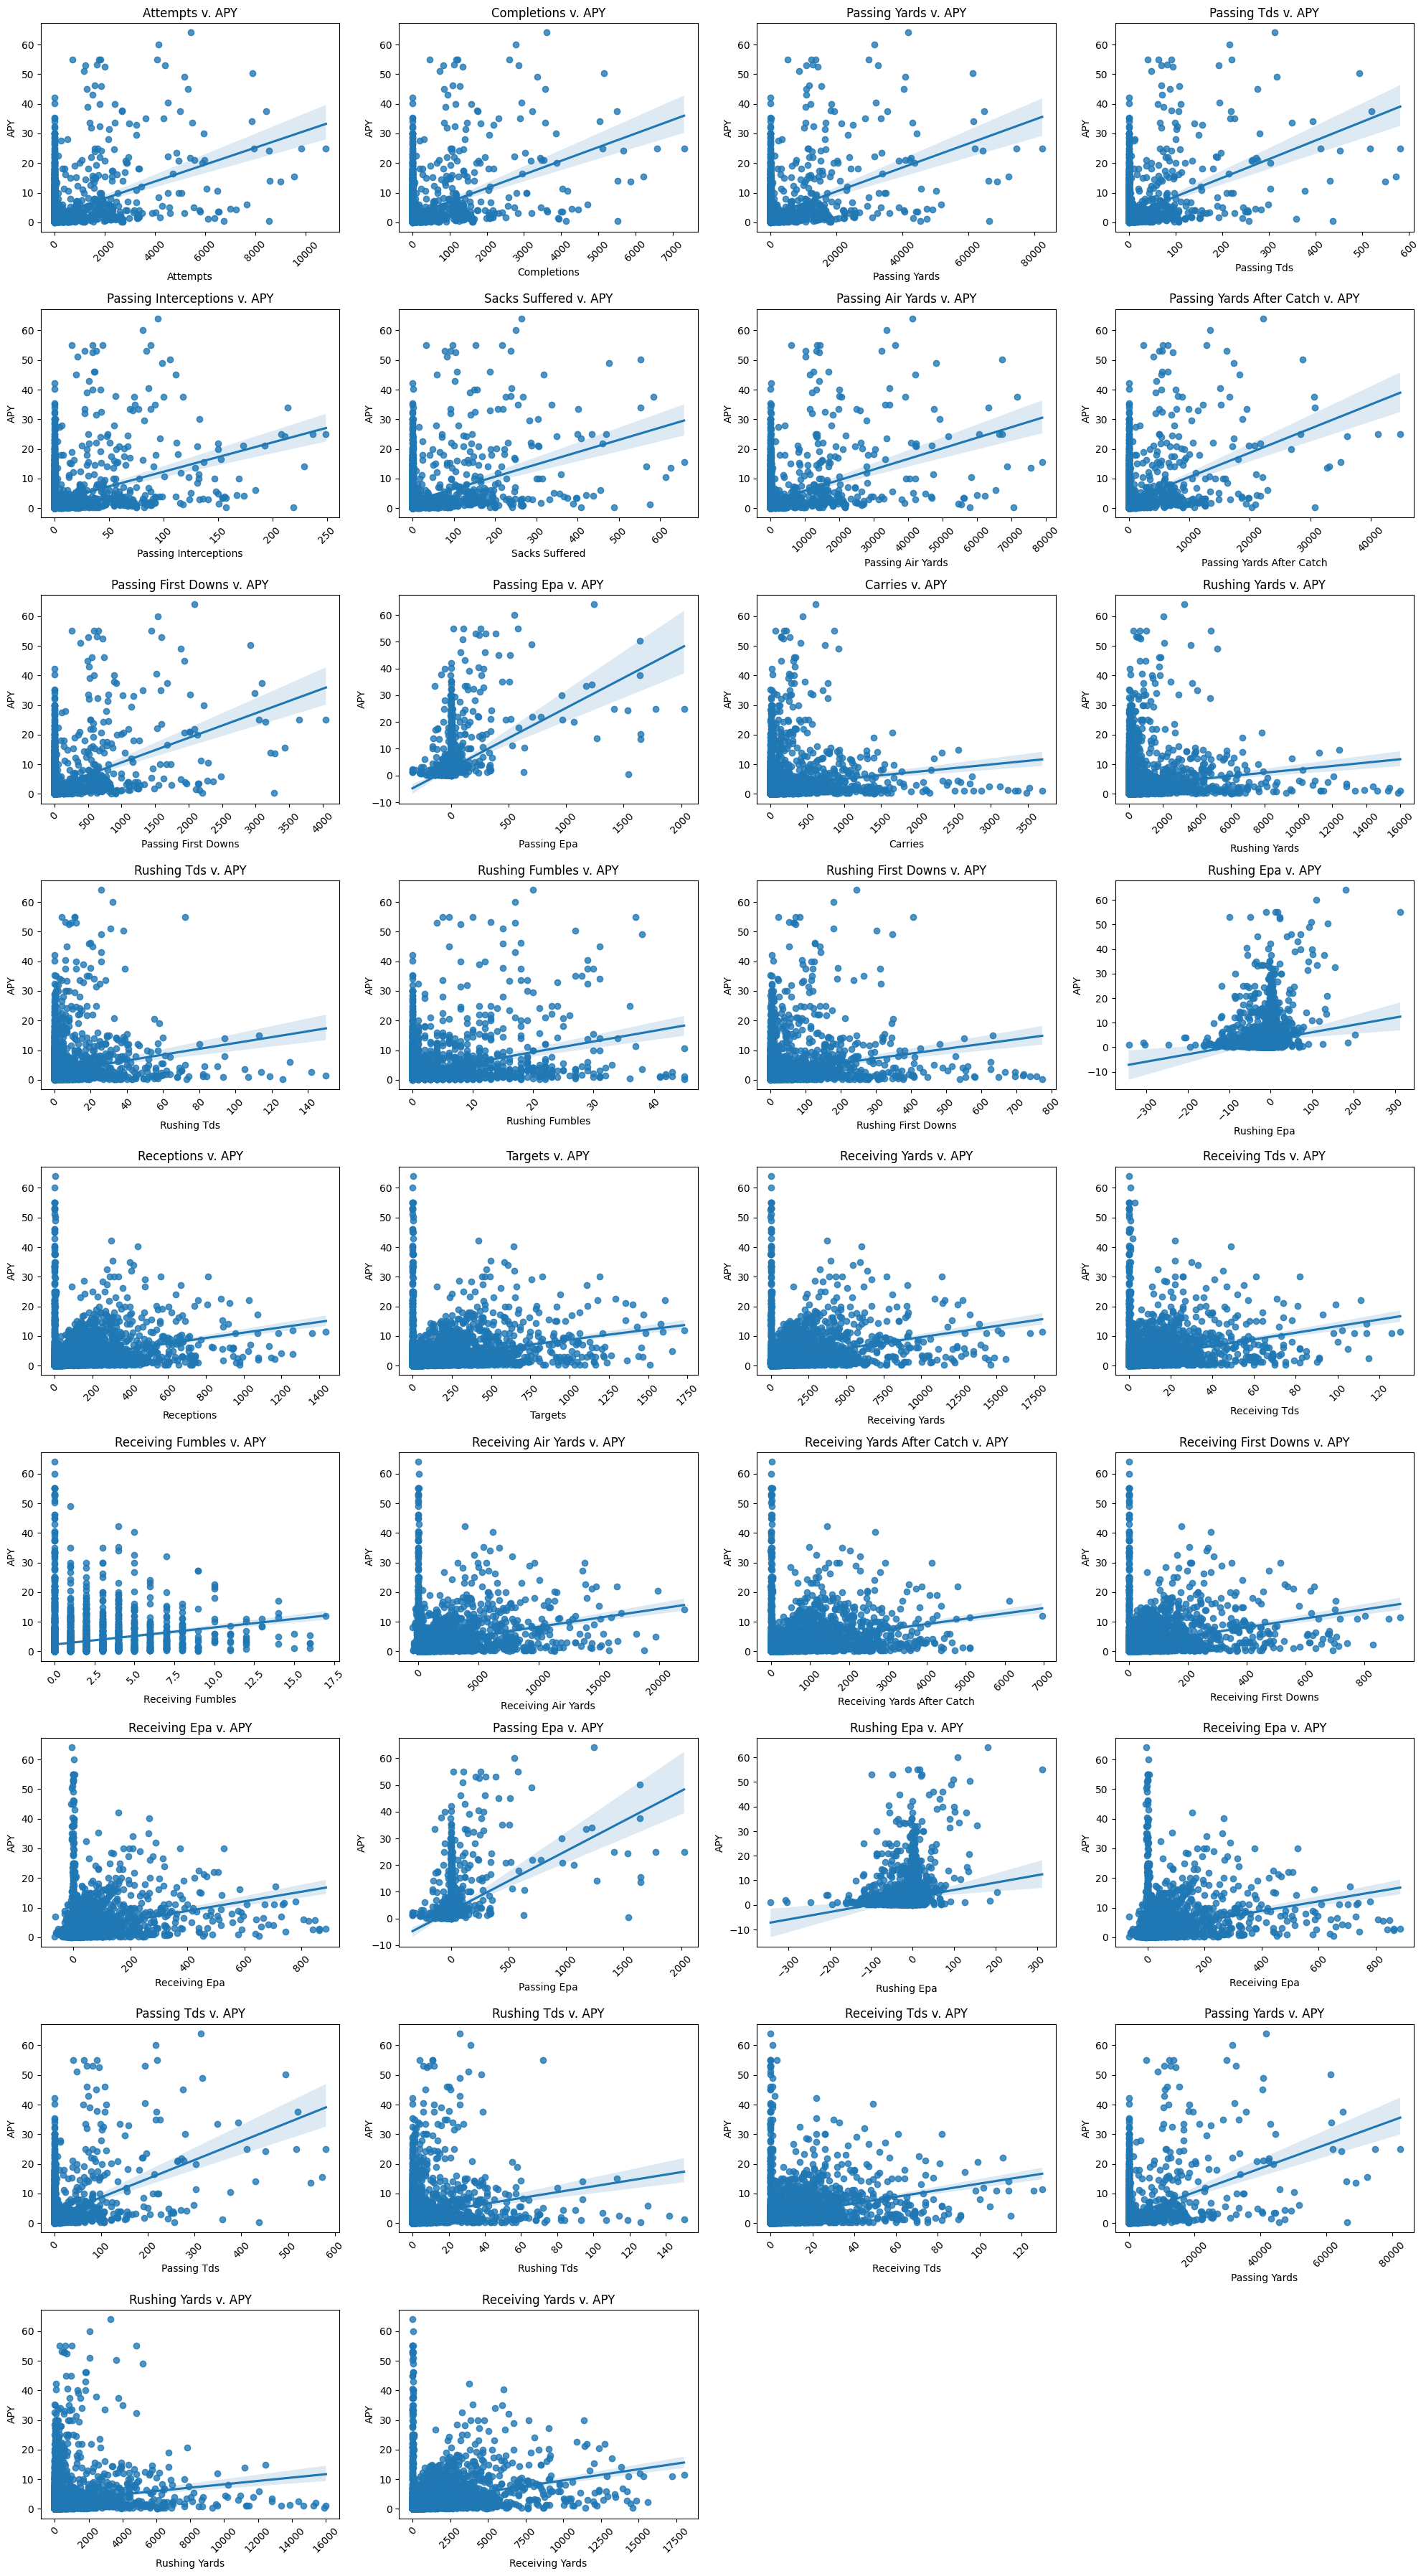

In [232]:
# Group all features and create regplots for them with sum aggregate of entire data set.
feature = stat_groups['passing'] + stat_groups['rushing'] + stat_groups['receiving'] + stat_groups['epas'] + stat_groups['tds'] + stat_groups['yds']
contract_means = regplot_array(cntrct_sum,feature)


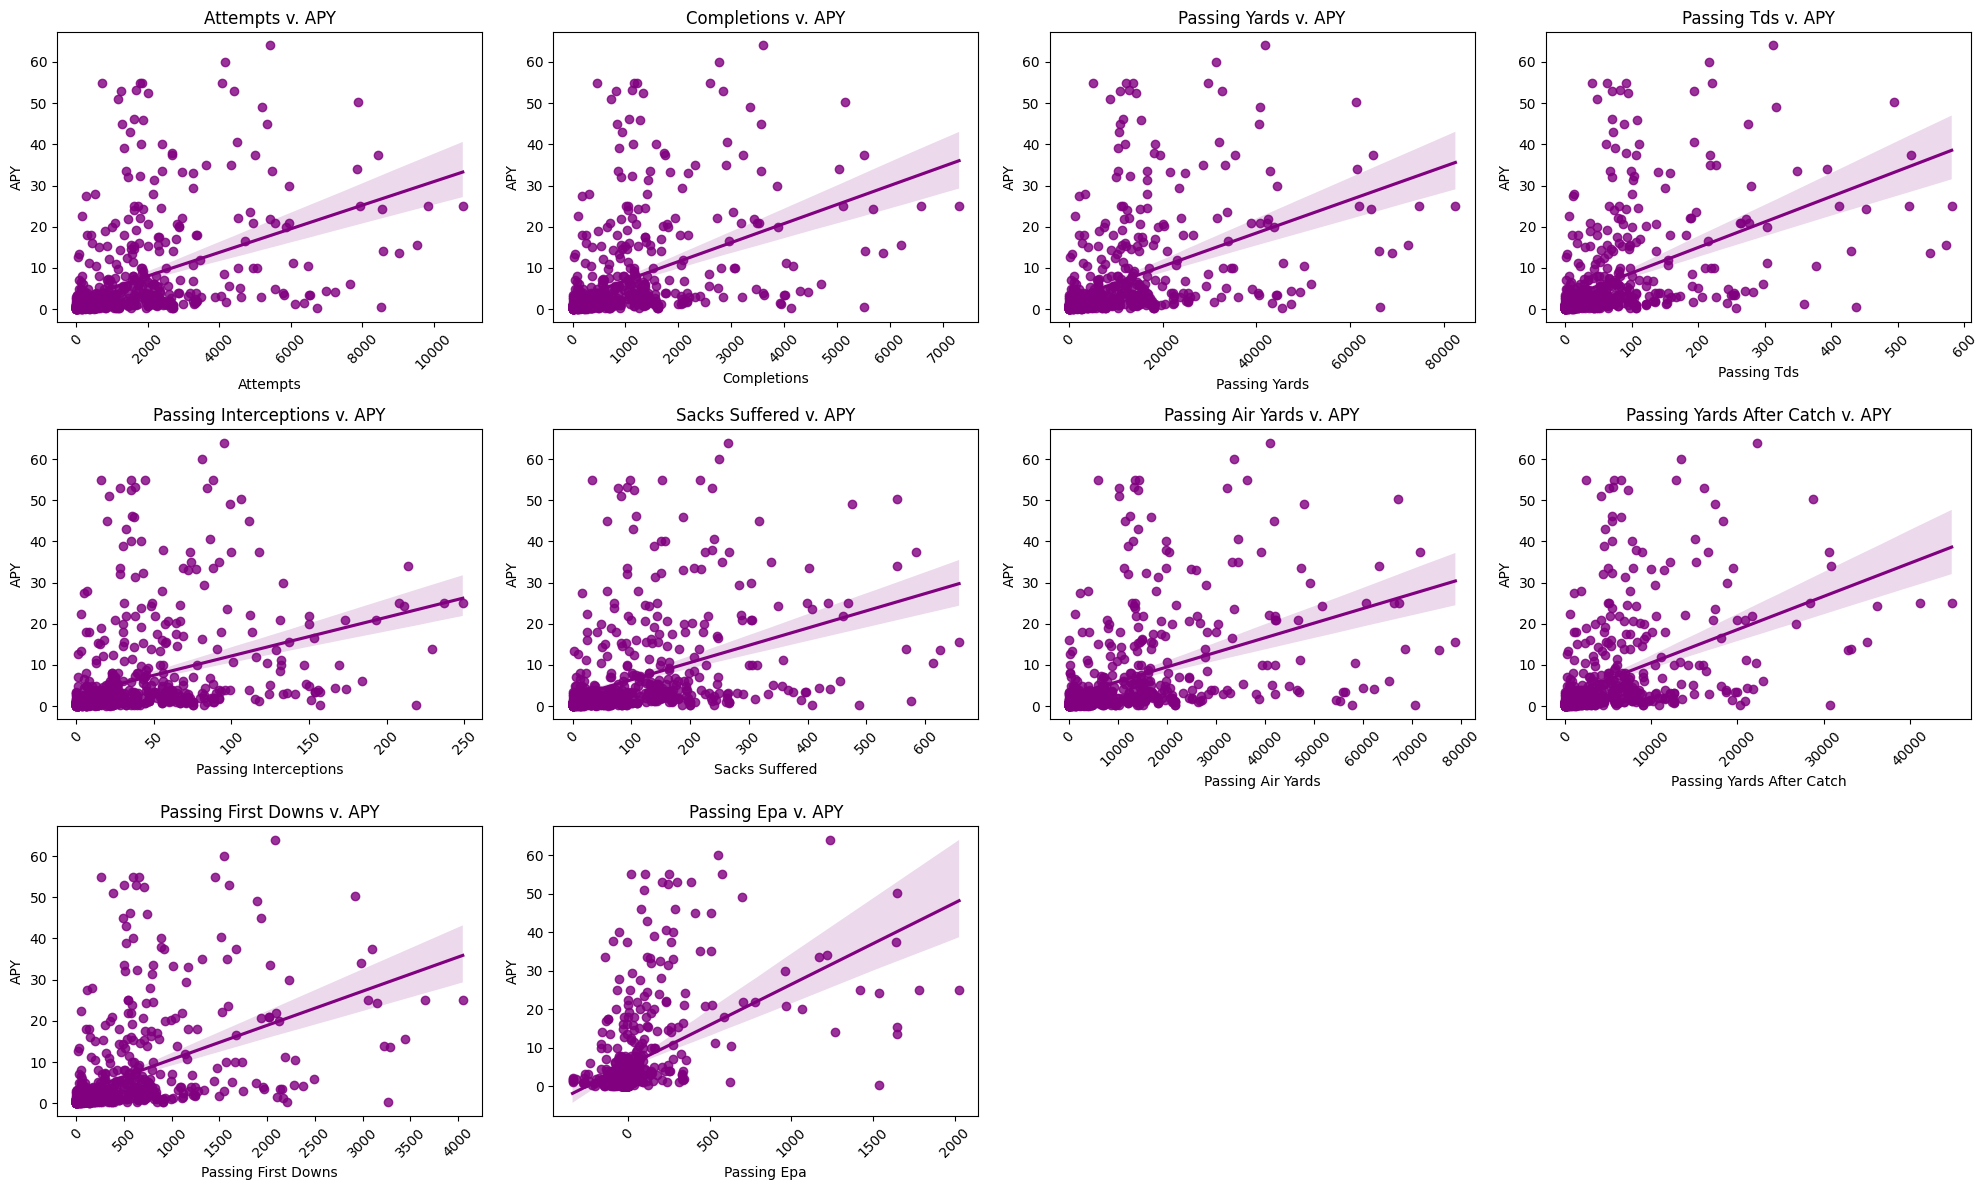

In [233]:
# Plotting QBs with all passing metrics.
qb_sums = regplot_array(qb_sum,stat_groups['passing'] , 'purple')

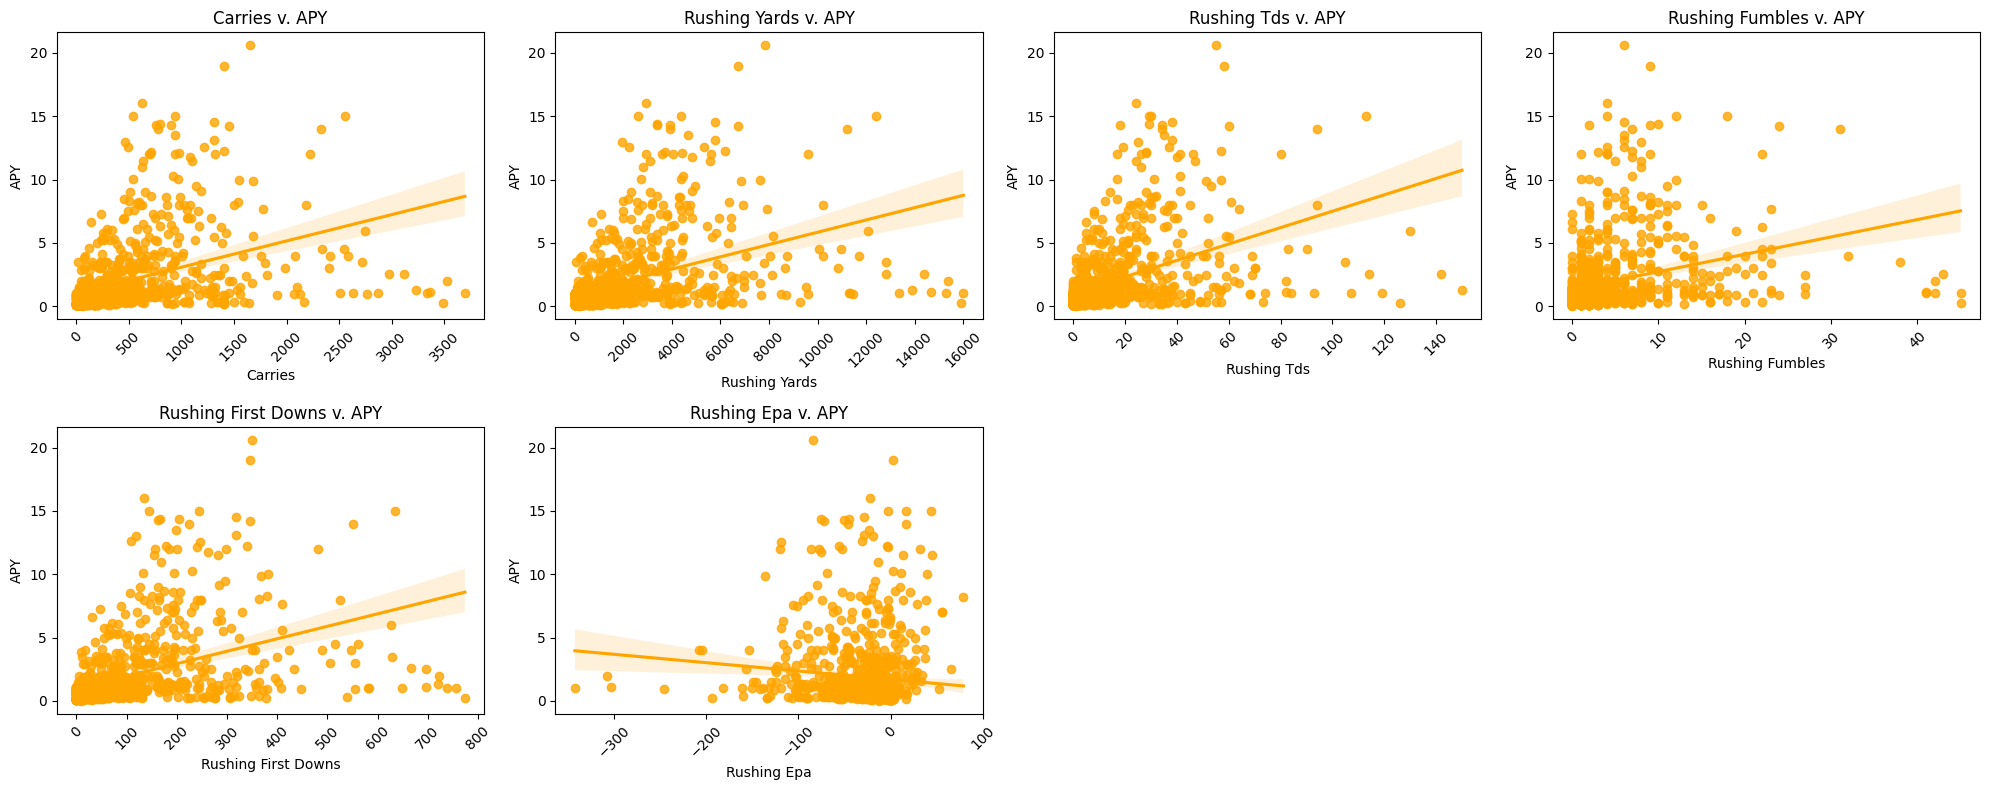

In [234]:
# Running back sums with all rushing metrics.
rb_sums = regplot_array(rb_sum,stat_groups['rushing'] , 'orange')

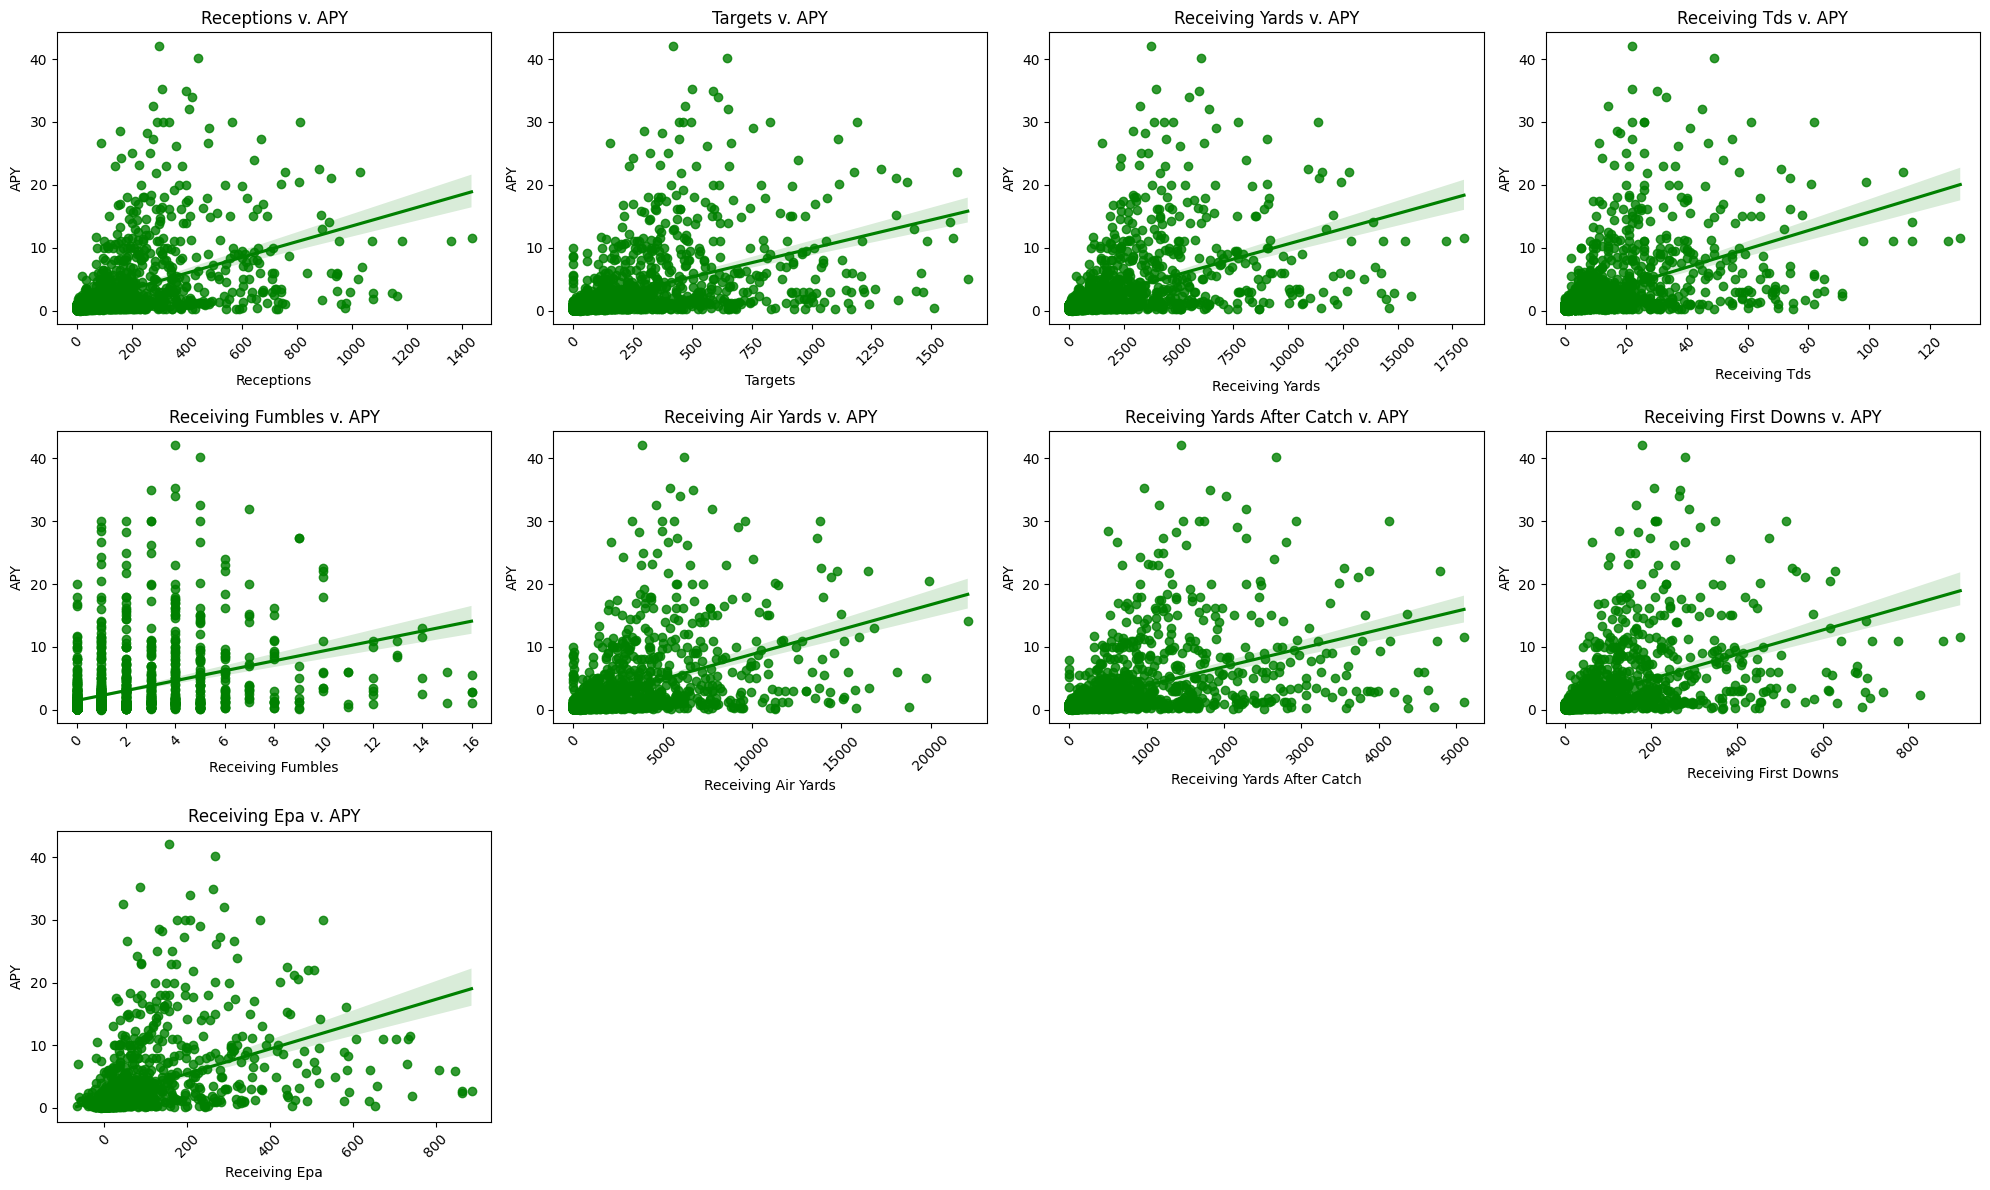

In [235]:
# WR sums for all receiving metrics.
wr_sums = regplot_array(wr_sum,stat_groups['receiving'] , 'green')

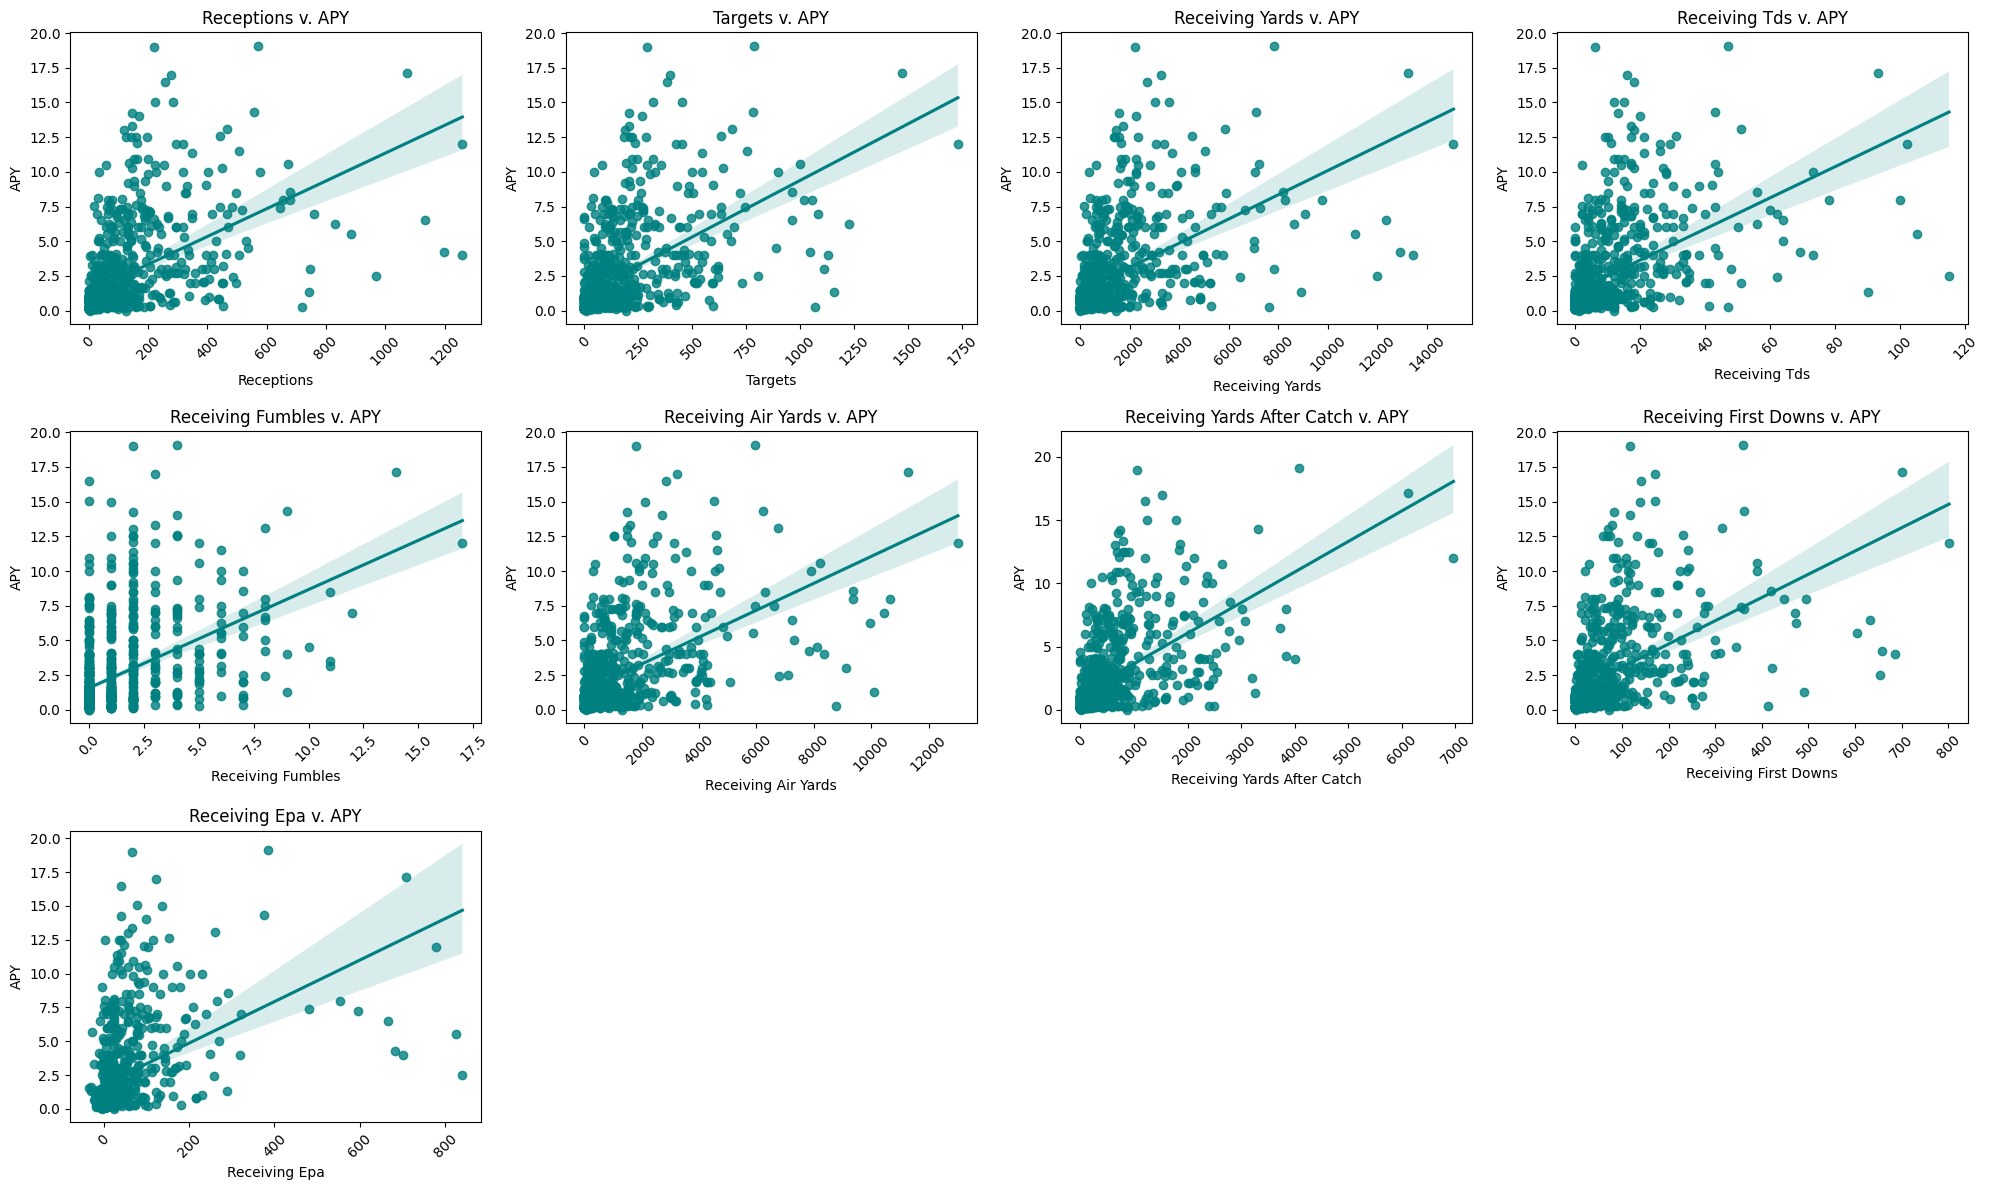

In [236]:
# TE sums for all receiving metrics .
te_sums = regplot_array(te_sum,stat_groups['receiving'] , 'teal')

We see that seperation by position allows for better learnings to be made overall. This is attributed to less entries where the specific values is 0 as it does not apply to the specific position group.  
We will now create some baseline Models for each of the groups above.

In [237]:
from sklearn.dummy import DummyRegressor
import time
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error

In [238]:
# Creating a function for running model experiments.
def run_model_experiments(data,target,features,model_dict,test_size=0.2,random_state=42):
  # Seperate data between features and target
  X = data[features]
  y = data[target]

  # Establish a test / train split.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  # Track results, trained models and store predictions for analysis.
  results = []
  trained_models = {}
  prediction_store = {}
  # Loop through dictionary of models given.
  for model_name, pipeline in model_dict.items():
    # Time training of Model
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    # Gather predictions of models.
    train_preds = pipeline.predict(X_train)
    test_preds = pipeline.predict(X_test)

    #RMSE
    train_rmse = root_mean_squared_error(y_train, train_preds)
    test_rmse = root_mean_squared_error(y_test, test_preds)

    #MAE
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    #R2
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    results.append({
        'Model': model_name,
        'Train_time': train_time,
        'Train_rmse': train_rmse,
        'Test_rmse': test_rmse,
        'Train_mae': train_mae,
        'Test_mae': test_mae,
        'Train_r2': train_r2,
        'Test_r2': test_r2,})

    trained_models[model_name] = pipeline
    prediction_store[model_name] = pd.DataFrame({
        'actual' : y_test,
        'predicted' : test_preds
    })
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Test_rmse', ascending=True)
  return {
      'results' : results_df,
      'models': trained_models,
      'predictions' : prediction_store
  }


In [239]:
# Seperate Features for Modeling of All data
cat_fts = ['position','contract_event','exp']
num_fts = [col for col in cntrct_sum.columns if col not in set(cat_fts + ['apy'])]

# Column Transformer for categorical and numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_fts),
        ('num', StandardScaler(), num_fts)
        ])

# PipeLines for all data.
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])


# Model Dictionary.
models = {
    'linear_reg' : lr_pipeline,
    'ridge' : ridge_pipeline,
    'lasso' : lasso_pipeline,
    }

In [240]:
# Feature seperation for position specific data
cat_ft = ['contract_event','exp']
num_ft = [col for col in qb_sum.columns if col not in set(cat_ft + ['apy'])]

# Column Transformer for categorical and numerical data
pos_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_ft),
        ('num', StandardScaler(), num_ft)
        ])

# Pipes for Position specific Data
poslr_pipeline = Pipeline([
    ('preprocessor', pos_preprocessor),
    ('regressor', LinearRegression())
])
posridge_pipeline = Pipeline([
    ('preprocessor', pos_preprocessor),
    ('regressor', Ridge())
])
poslasso_pipeline = Pipeline([
    ('preprocessor', pos_preprocessor),
    ('regressor', Lasso())
])

# Position Models Dictionary
pos_models = {
    'linear_reg' : poslr_pipeline,
    'ridge' : posridge_pipeline,
    'lasso' : poslasso_pipeline,
    }

In [241]:
# Model for all data.
tot_results = run_model_experiments(cntrct_sum, 'apy', cat_fts + num_fts, models)

In [242]:
# Model for QB only data
qb_results = run_model_experiments(qb_sum, 'apy', cat_ft + num_ft, pos_models)

In [243]:
# Model for RB only data
rb_results = run_model_experiments(rb_sum, 'apy', cat_ft + num_ft, pos_models)

In [244]:
# Model for WR only data
wr_results = run_model_experiments(wr_sum, 'apy', cat_ft + num_ft, pos_models)

In [245]:
# Model for TE only data
te_results = run_model_experiments(te_sum, 'apy', cat_ft + num_ft, pos_models)

In [246]:
tot_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
0,linear_reg,0.039624,4.125441,4.410810,2.345372,2.356618,0.511014,0.405244
1,ridge,0.077152,4.170966,4.465297,2.358367,2.373578,0.500163,0.390460
2,lasso,0.027327,5.211660,5.047891,2.807669,2.749831,0.219618,0.221028


In [247]:
qb_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
2,lasso,0.032717,9.110337,7.984620,5.507356,4.981580,0.336352,0.359135
1,ridge,0.027172,7.448443,9.273942,4.979865,5.170025,0.556392,0.135456
0,linear_reg,0.019087,7.241363,10.047606,4.854453,5.473997,0.580715,-0.014807


In [248]:
rb_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
1,ridge,0.016798,1.914393,2.177029,1.247859,1.377376,0.527028,0.472713
0,linear_reg,0.012724,1.874411,2.191702,1.231981,1.370122,0.546578,0.465581
2,lasso,0.014127,2.675126,2.871860,1.700439,1.775529,0.076448,0.082417


In [249]:
wr_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
0,linear_reg,0.045985,3.426718,3.637015,1.997777,2.098341,0.501136,0.556701
1,ridge,0.039811,3.457520,3.679128,1.986865,2.116761,0.492128,0.546376
2,lasso,0.022208,4.309096,4.867487,2.335363,2.617036,0.211144,0.206008


In [250]:
te_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
1,ridge,0.015144,2.031134,2.481734,1.387286,1.525761,0.560258,0.394894
0,linear_reg,0.016001,1.978845,2.562309,1.348301,1.598914,0.582608,0.354964
2,lasso,0.013393,2.690976,2.928333,1.885614,1.954609,0.228137,0.157516


From the baseline models created above with a basic aggregation of stats leading up to the contract event, we see that the positional models performed better than the grouped model with all positions for all but 1 position, the Quarterback position. This is understandable as the QB position is one that is critiqued on much more than overall stat accumulation. Efficiency metrics are important to consider for this group especially to improve the model performance.  
Further Feature Engineering and Model Experimentation will take place in a second notebook for this project.

In [254]:
# Save all DataFrames for utilization in new notebook without requiring cleaning all again.
final_dfs

['tot_plyr_sts',
 'contract_final',
 'tot_tm_sts',
 'tot_qb_rcds',
 'tot_tm_rcds',
 'tot_plyr_sts_rcds',
 'contracts_w_stats']

In [264]:
import zipfile

dfs = {
    'filtered_player_stats' : off_player_stats,
    'team_stats' : team_stats,
    'filtered_contract' : contracts_filtered,
    'total_player_stats': tot_plyr_sts,
    'contracts_final' : contract_final,
    'total_team_stats': tot_tm_sts,
    'total_qb_records': tot_qb_rcds,
    'total_team_records': tot_tm_rcds,
    'total_player_stats_records': tot_plyr_sts_rcds,
    'contracts_w_stats': contracts_w_stats,
}

with zipfile.ZipFile('nfl_dfs.zip', 'w') as zf:
  for name, df in dfs.items():
    csv_name = f'{name}.csv'
    df.to_csv(csv_name, index=False)
    zf.write(csv_name)

from google.colab import files
files.download('nfl_dfs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>